<a href="https://colab.research.google.com/github/uiinlee/colab/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os


zip_file_path = '/content/drive/MyDrive/watch_ring/250428.zip'
extract_to_path = '/content/drive/MyDrive/watch_ring/250428'

os.makedirs(extract_to_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:

        zip_ref.extractall(extract_to_path)
    print(f"파일 압축 해제 완료: '{zip_file_path}' -> '{extract_to_path}'")
except zipfile.BadZipFile:
    print(f"오류: '{zip_file_path}' 파일이 유효한 zip 파일이 아니거나 손상되었습니다.")
except FileNotFoundError:
    print(f"오류: '{zip_file_path}' 파일을 찾을 수 없습니다.")
except Exception as e:
    print(f"알 수 없는 오류 발생: {e}")

파일 압축 해제 완료: '/content/drive/MyDrive/watch_ring/250428.zip' -> '/content/drive/MyDrive/watch_ring/250428'


In [2]:
import zipfile
import os


zip_file_path = '/content/drive/MyDrive/watch_ring/250429.zip'
extract_to_path = '/content/drive/MyDrive/watch_ring/250429'

os.makedirs(extract_to_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:

        zip_ref.extractall(extract_to_path)
    print(f"파일 압축 해제 완료: '{zip_file_path}' -> '{extract_to_path}'")
except zipfile.BadZipFile:
    print(f"오류: '{zip_file_path}' 파일이 유효한 zip 파일이 아니거나 손상되었습니다.")
except FileNotFoundError:
    print(f"오류: '{zip_file_path}' 파일을 찾을 수 없습니다.")
except Exception as e:
    print(f"알 수 없는 오류 발생: {e}")

파일 압축 해제 완료: '/content/drive/MyDrive/watch_ring/250429.zip' -> '/content/drive/MyDrive/watch_ring/250429'


데이터 로드 완료: shape = (9141, 24)
Acc 기반 추출 세그먼트: [(np.int64(0), np.int64(631)), (np.int64(1183), np.int64(1871)), (np.int64(2216), np.int64(3031)), (np.int64(3413), np.int64(4093)), (np.int64(4381), np.int64(5223)), (np.int64(5588), np.int64(6490)), (np.int64(6789), np.int64(7514)), (np.int64(7951), np.int64(9140))]


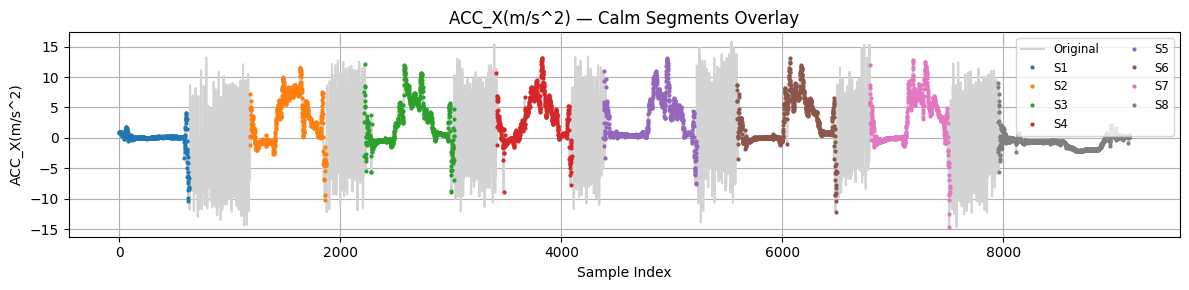

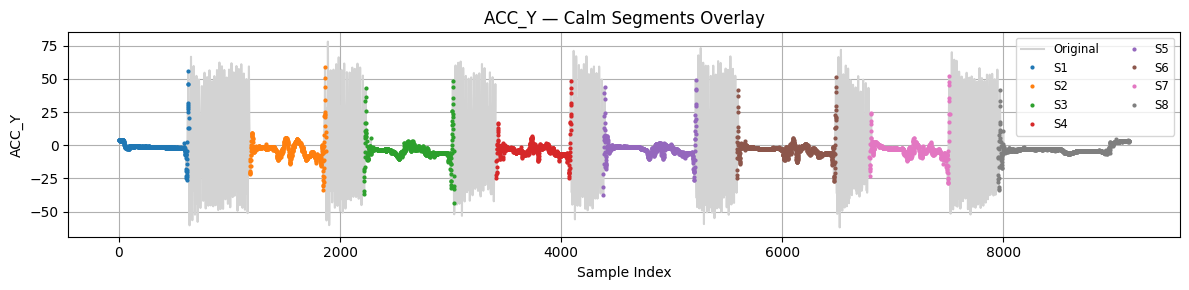

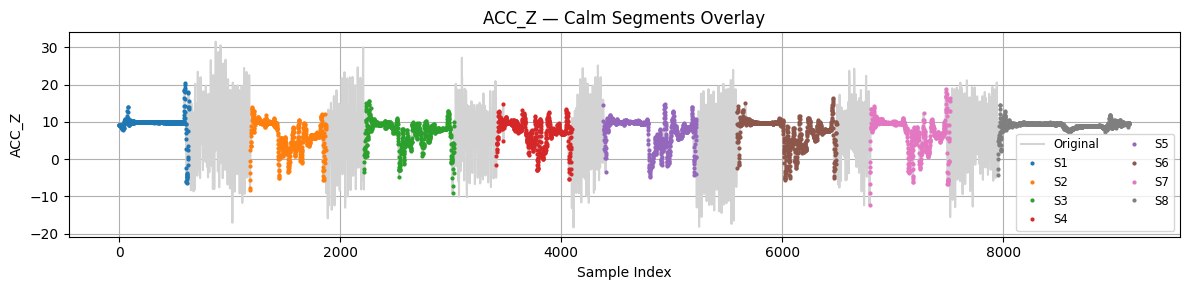

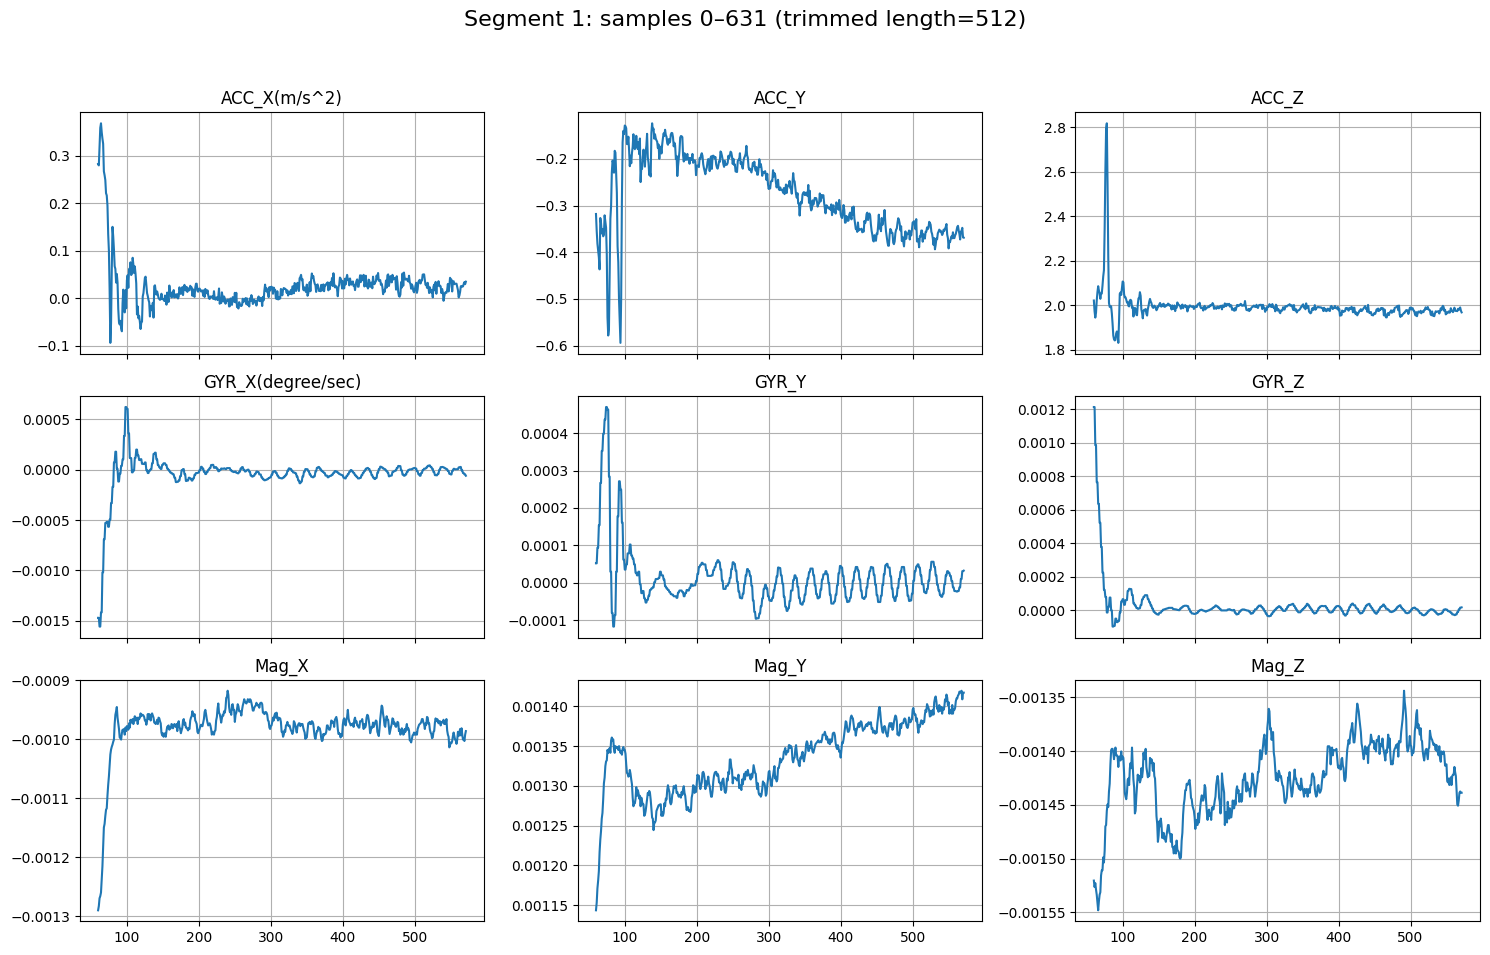

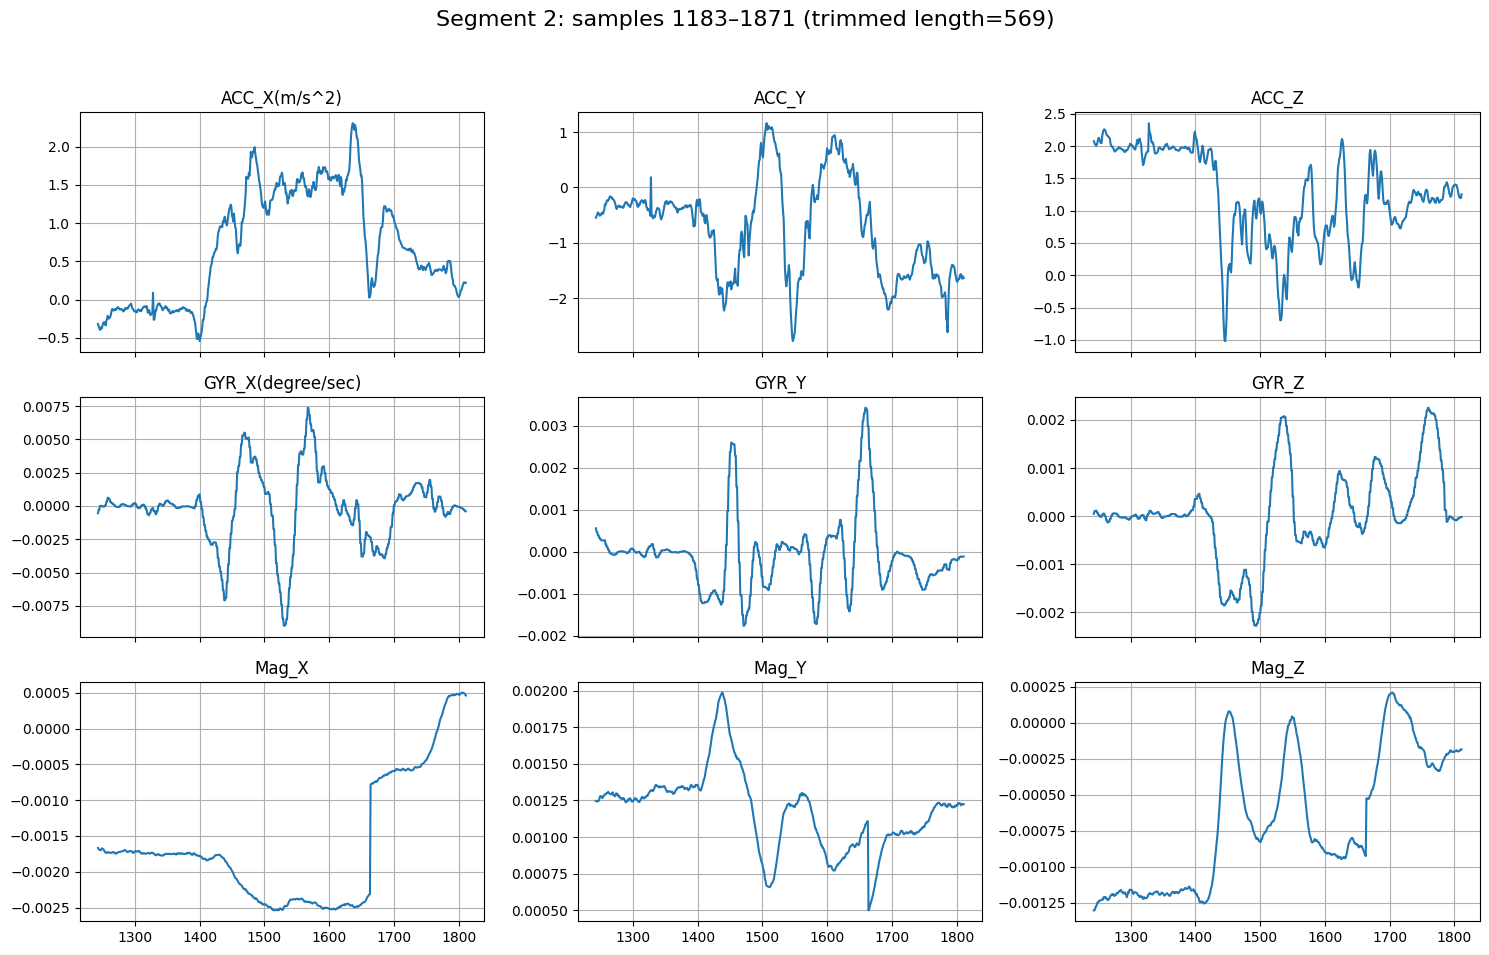

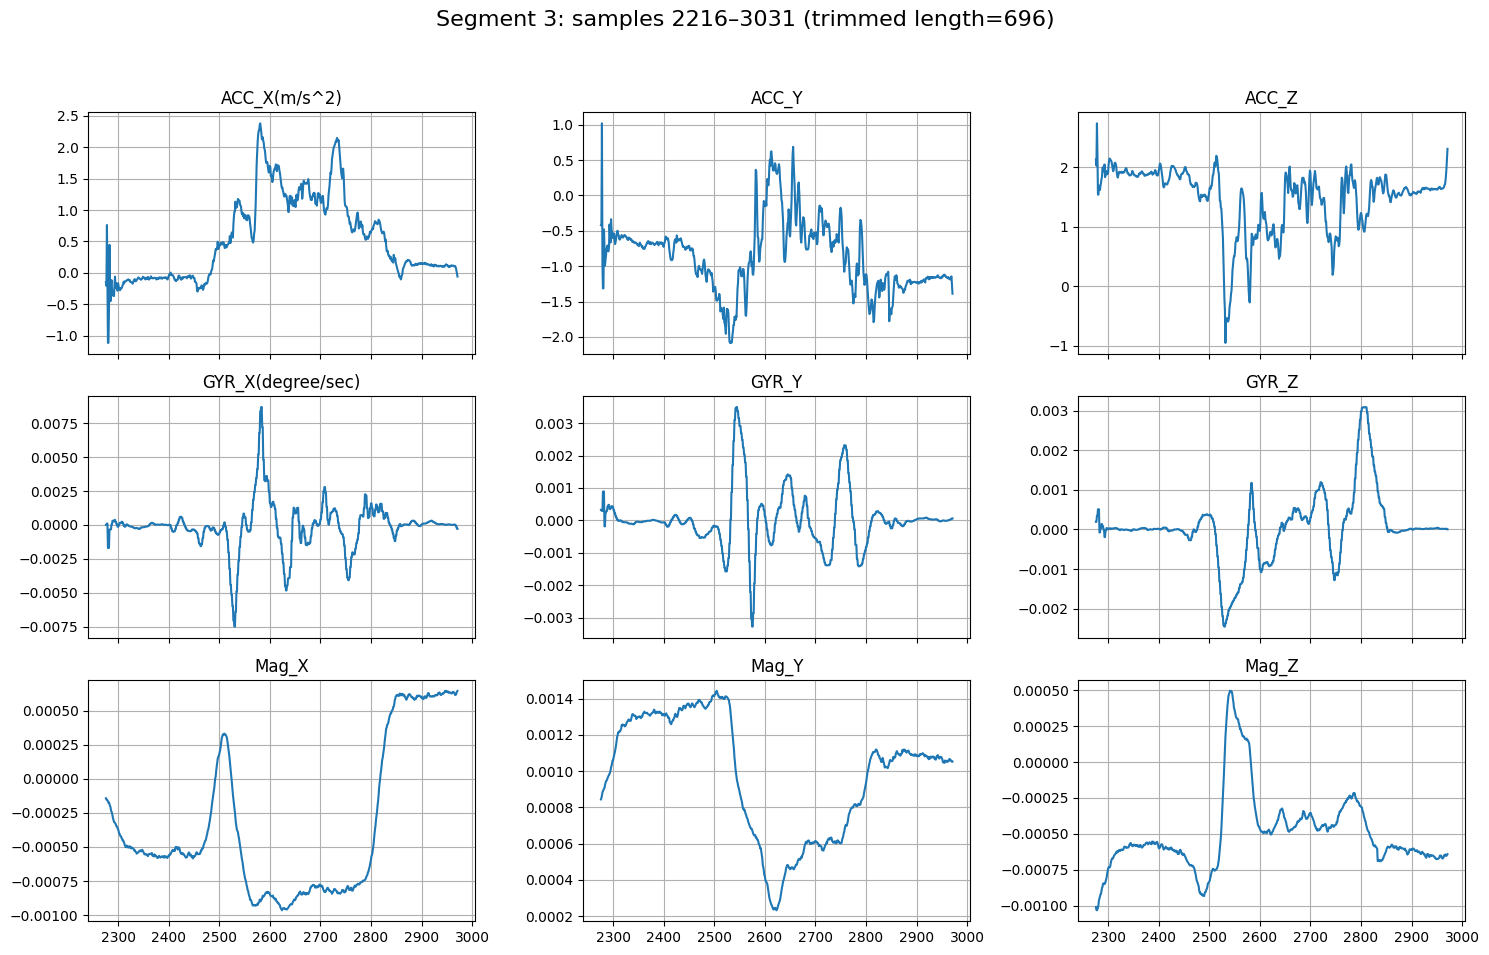

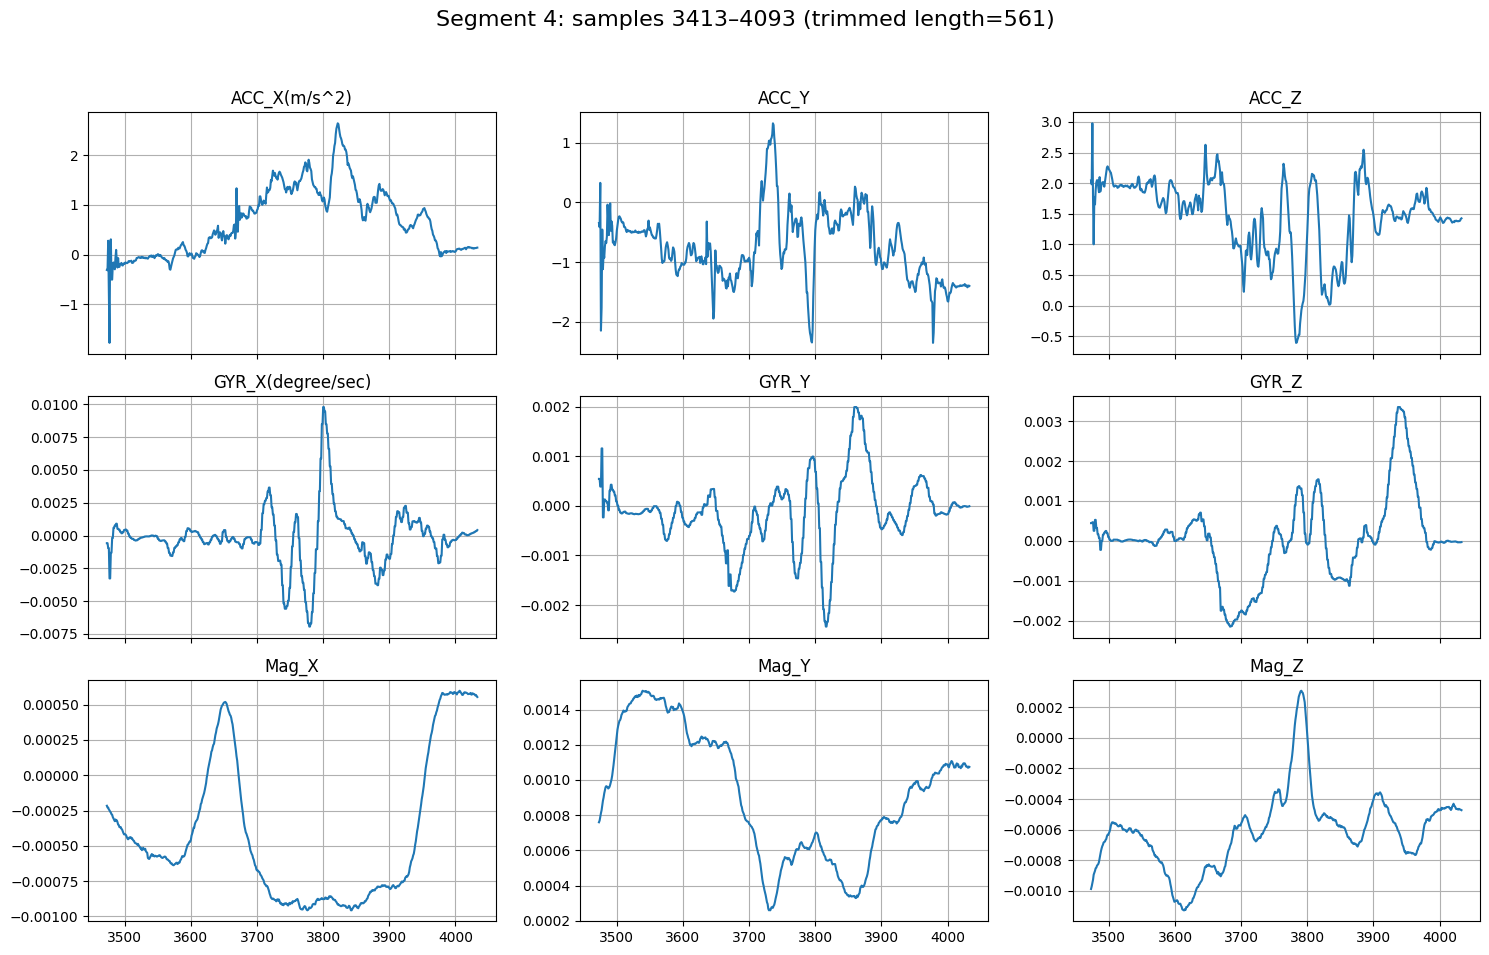

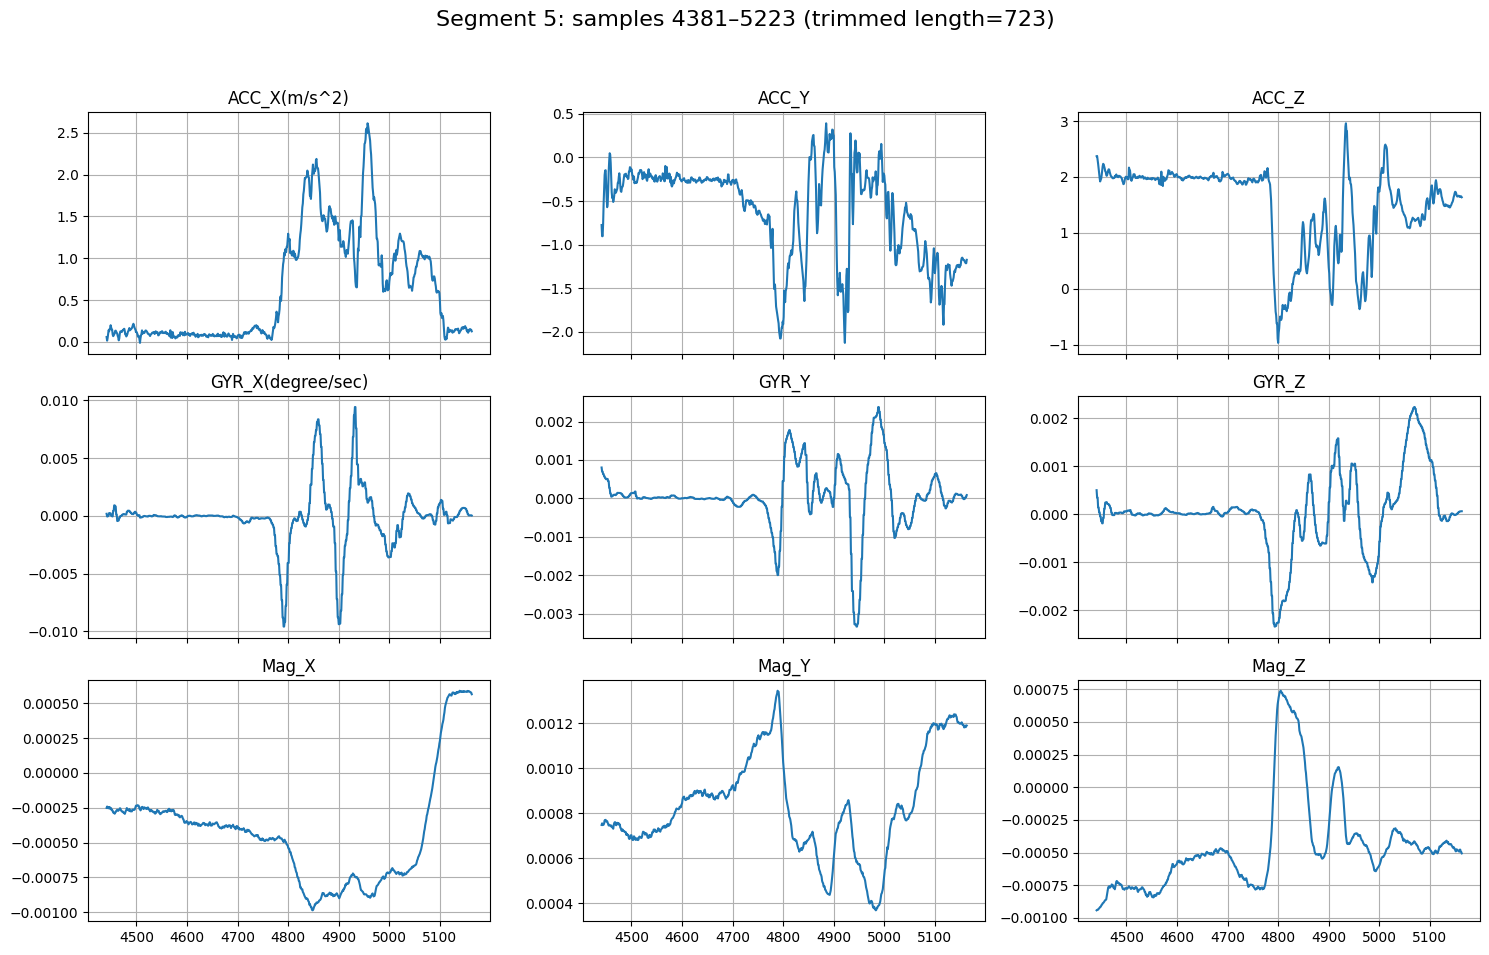

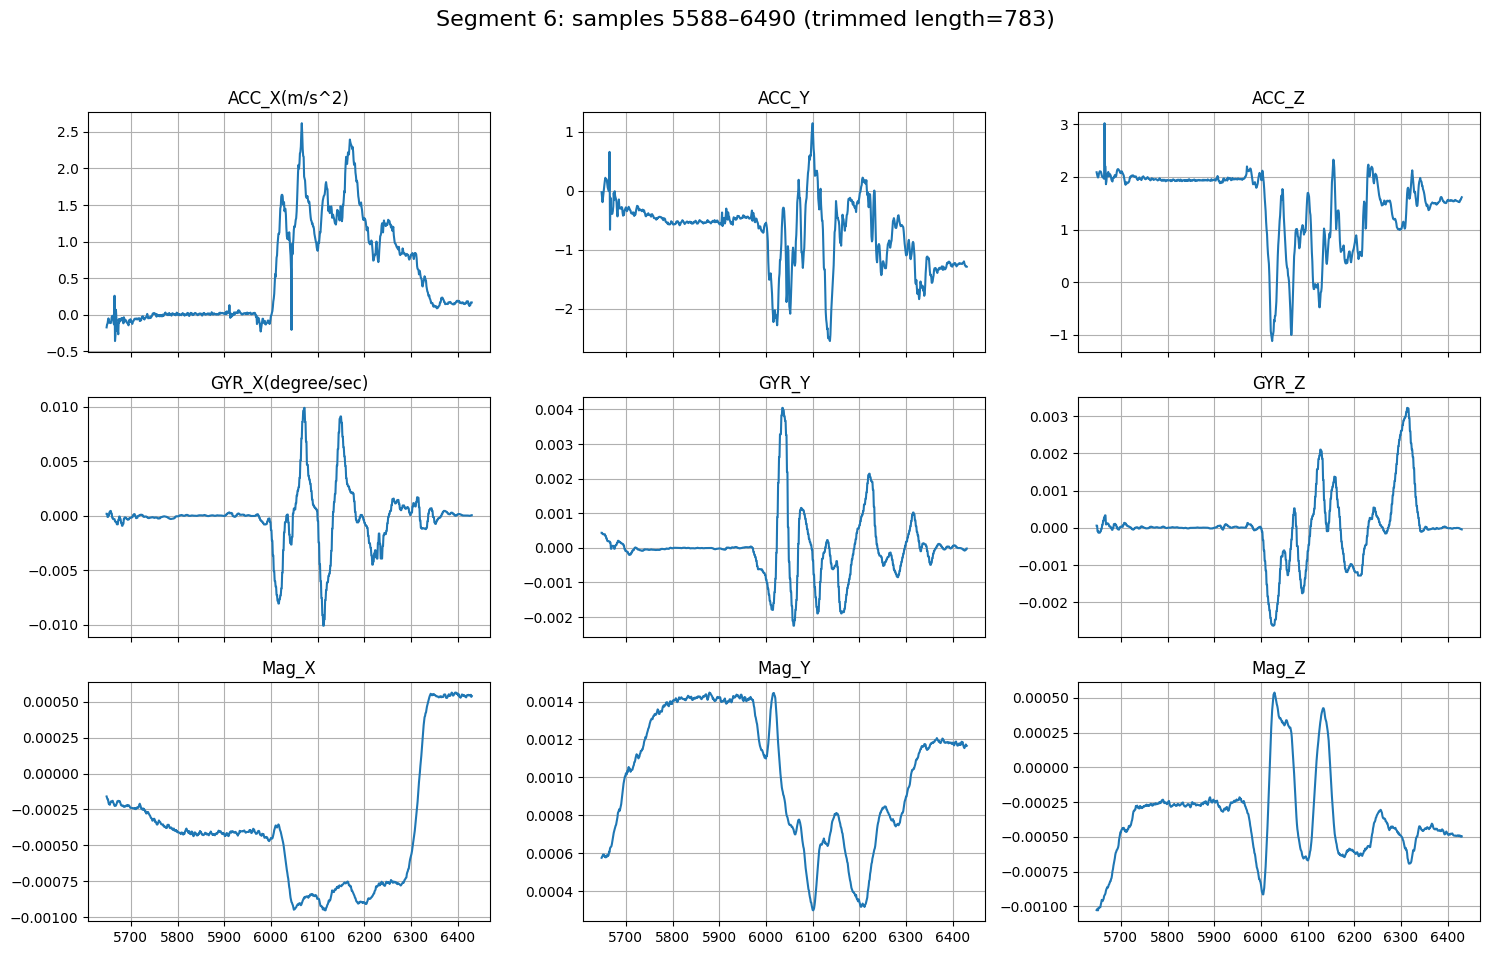

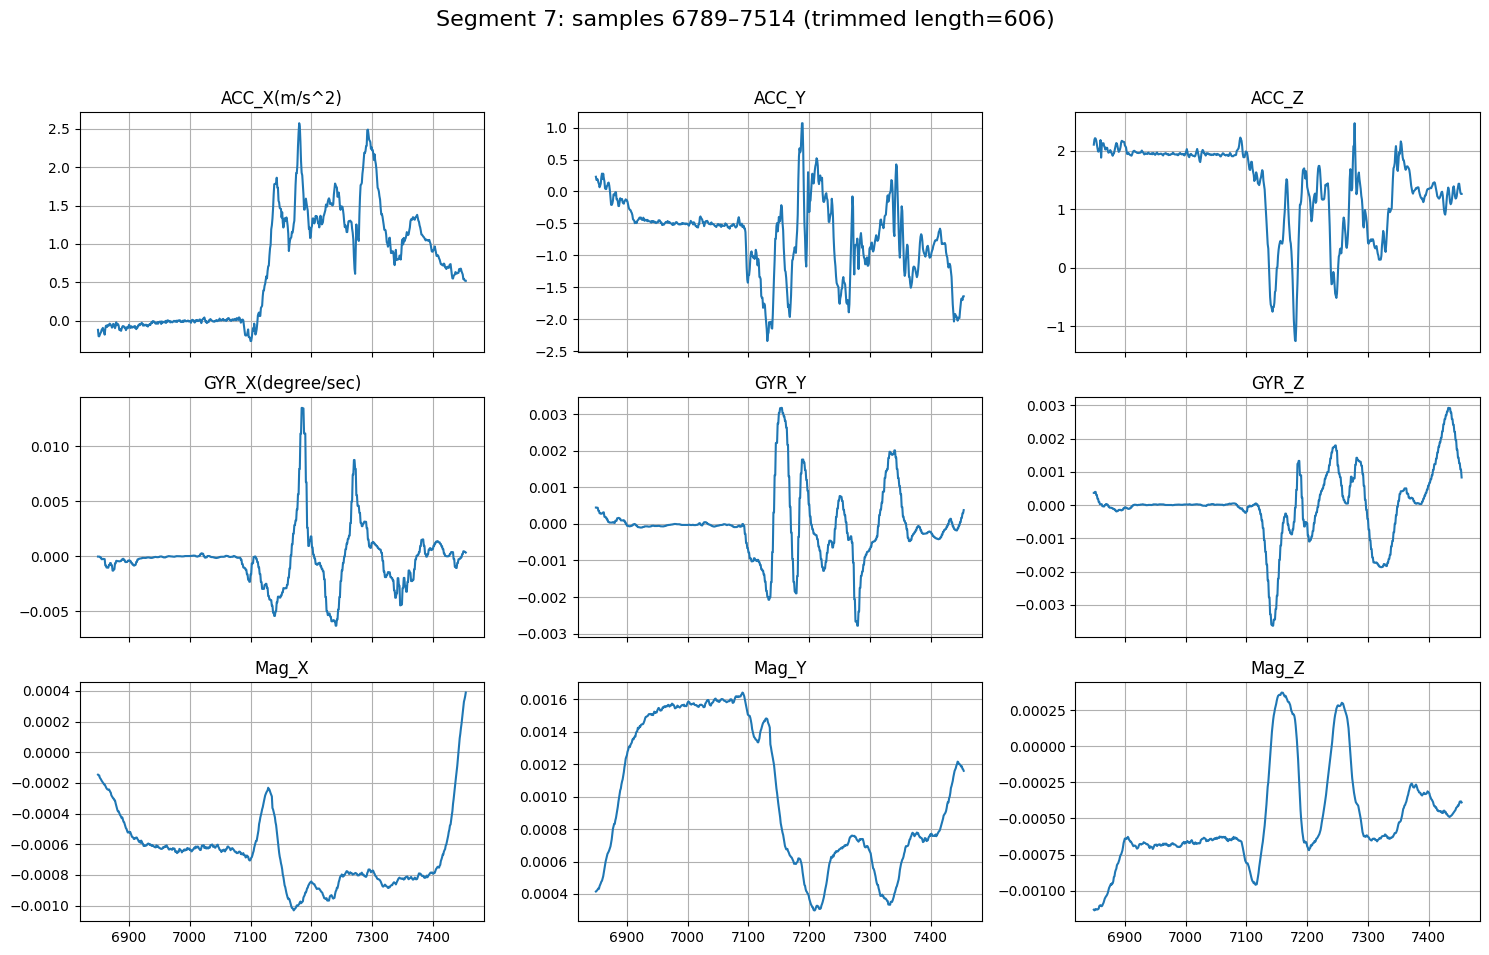

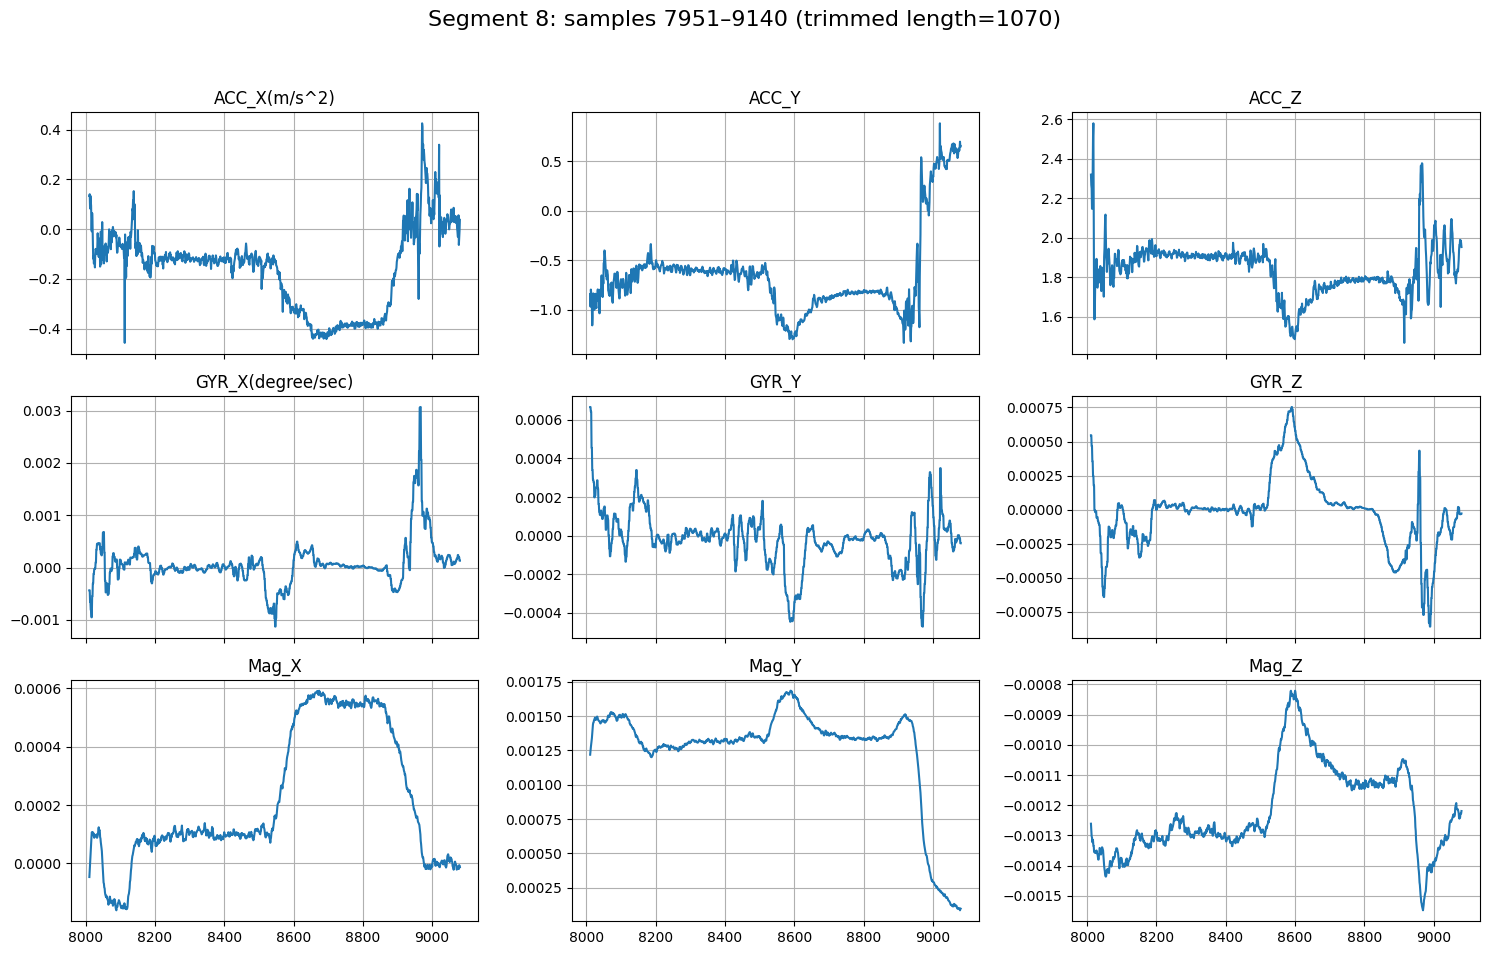

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1) 파일 로드 ---
right_ring_path = (
    '/content/drive/MyDrive/watch_ring/250429/01June_2011_Wednesday_heute-944/left_watch/fusion_20240416-113440.csv'
)
df = pd.read_csv(right_ring_path, encoding='utf-8')
print(f"데이터 로드 완료: shape = {df.shape}")

# --- 2) 파라미터 ---
STD_QUANTILE  = 0.95
MIN_DURATION  = 10
VAL_THRESH    = 20
LENGTH_THRESH = 300
TRIM          = 60   # <-- 앞뒤로 잘라낼 샘플 수


# --- 3) Acc 채널 기반 세그먼트 추출 함수 ---
def extract_acc_segments(df, channels, window, std_q, min_dur, val_thresh, length_thresh):
    rs = df[channels].rolling(window=window, center=True).std().ffill().bfill().fillna(0)
    th = rs.quantile(std_q)
    calm_mask = np.logical_and.reduce([rs[ch] < th[ch] for ch in channels])
    calm_mask = pd.Series(calm_mask, index=df.index)

    diff   = calm_mask.astype(int).diff().fillna(0)
    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0]
    if calm_mask.iloc[0]:
        starts = np.insert(starts, 0, 0)
    if calm_mask.iloc[-1]:
        ends = np.append(ends, len(calm_mask)-1)

    segs = []
    for s, e in zip(starts, ends):
        length = e - s + 1
        if length < min_dur:
            continue
        if df[channels].iloc[s:e+1].abs().max().max() <= val_thresh:
            continue
        if length <= length_thresh:
            continue
        segs.append((s, e))
    return segs

# --- 4) Acc 기반 세그먼트 계산 ---
acc_channels = ['ACC_X(m/s^2)','ACC_Y','ACC_Z']
gyr_channels = ['GYR_X(degree/sec)','GYR_Y', 'GYR_Z']
# mag_channels = ['Mag_X', 'Mag_Y', 'Mag_Z']
acc_segs = extract_acc_segments(
    df, acc_channels,
    window=WINDOW,
    std_q=STD_QUANTILE,
    min_dur=MIN_DURATION,
    val_thresh=VAL_THRESH,
    length_thresh=LENGTH_THRESH
)
print("Acc 기반 추출 세그먼트:", acc_segs)

# --- 5) aligned_segs 재생성: 각 채널에 동일 (s,e) 적용 ---
ppg_channels = ['GYR_X(degree/sec)','GYR_Y', 'GYR_Z', 'Mag_X', 'Mag_Y', 'Mag_Z']
all_channels = acc_channels + ppg_channels



aligned_segs = {ch: [] for ch in all_channels}
for s, e in acc_segs:
    for ch in all_channels:
        aligned_segs[ch].append(df[ch].iloc[s:e+1])

# --- 6) 채널별 정규화 함수 정의 ---
def tanh1(x):
    x_scaled = [v * 1e-5 for v in x]
    def _tanh(v):
        v_clip = max(-20, min(20, v))
        return (math.exp(v_clip) - math.exp(-v_clip)) / (math.exp(v_clip) + math.exp(-v_clip))
    out = [_tanh(x_scaled[0])] + [_tanh(v)*2 for v in x_scaled[1:]]
    return [v * 10000 for v in out]

def tanh2(x):
    x_scaled = [v * 1e-5 for v in x]
    def _tanh(v):
        v_clip = max(-20, min(20, v))
        return (math.exp(v_clip) - math.exp(-v_clip)) / (math.exp(v_clip) + math.exp(-v_clip))
    # 첫 원소도 포함해 전부 *2 처리
    return [_tanh(v)*2 for v in x_scaled]

transform_map = {ch: tanh1 for ch in acc_channels}
transform_map.update({ch: tanh2 for ch in ppg_channels})

# --- 7) 시각화: ACC 채널 전체 + 세그먼트 오버레이 (원본 그대로) ---
for ch in acc_channels:
    plt.figure(figsize=(12, 3))
    plt.plot(df[ch], color='lightgray', label='Original')
    for idx, seg in enumerate(aligned_segs[ch], 1):
        plt.plot(seg.index, seg.values, '.', markersize=4, label=f'S{idx}')
    plt.title(f'{ch} — Calm Segments Overlay')
    plt.xlabel('Sample Index')
    plt.ylabel(ch)
    plt.legend(fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --- 8) 최종: 세그먼트별 3×3 플롯 (tanh → trim 순서) ---
for idx, (s, e) in enumerate(acc_segs, 1):
    raw_seg = df.iloc[s:e+1]
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
    axes = axes.flatten()

    for ax, ch in zip(axes, all_channels):
        # 1) 전체 raw segment에 tanh 적용
        norm_full = transform_map[ch]( raw_seg[ch].tolist() )
        # 2) 적용 후 앞뒤 TRIM만큼 잘라내기
        norm_trim = norm_full[TRIM : len(norm_full)-TRIM]
        idxs = raw_seg.index[TRIM : len(raw_seg)-TRIM]

        ax.plot(idxs, norm_trim)
        ax.set_title(ch)
        ax.grid(True)

    # 남은 축 없애기
    for ax in axes[len(all_channels):]:
        ax.axis('off')

    fig.suptitle(
        f'Segment {idx}: samples {s}–{e} (trimmed length={e-s+1-2*TRIM})',
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

데이터 로드 완료: shape = (2255, 38)
원본 Acc 기반 추출 세그먼트: [(np.int64(291), np.int64(468)), (np.int64(555), np.int64(757)), (np.int64(850), np.int64(1024)), (np.int64(1086), np.int64(1308)), (np.int64(1394), np.int64(1626)), (np.int64(1698), np.int64(1871)), (np.int64(1966), np.int64(2254))]


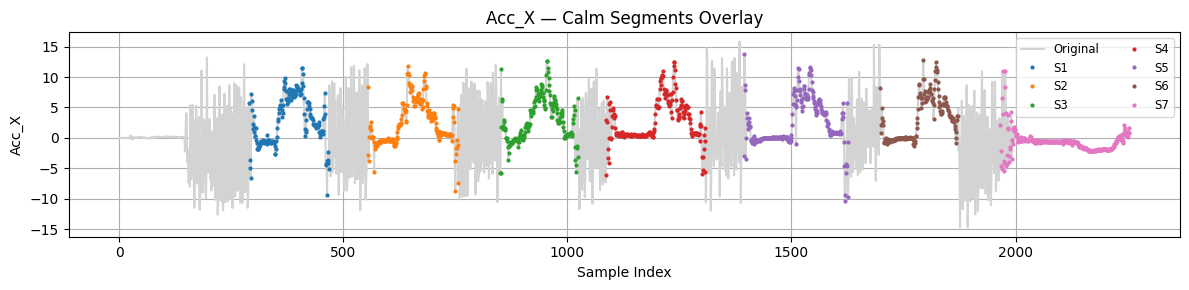

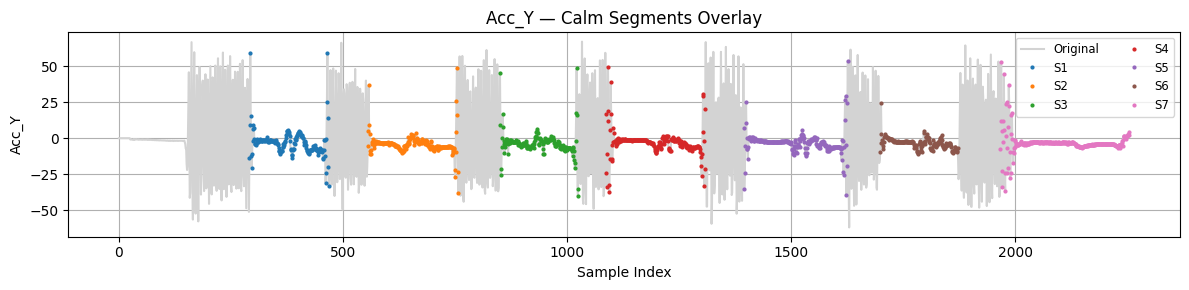

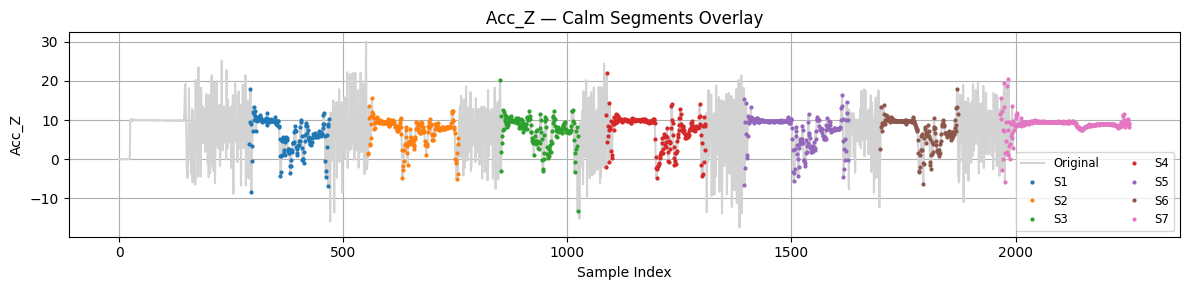

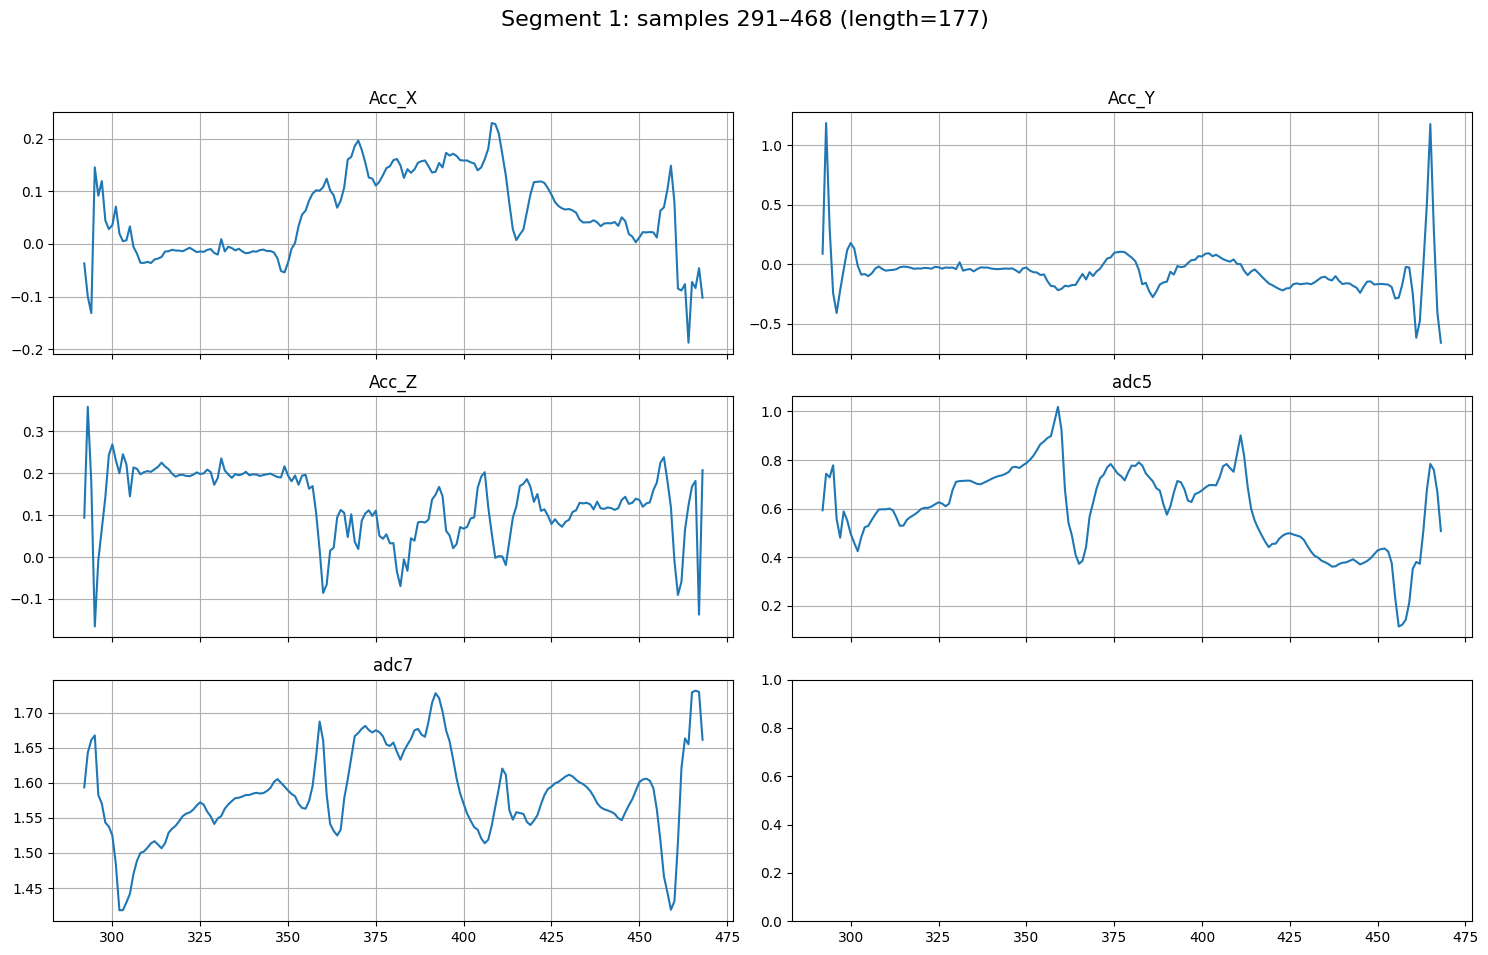

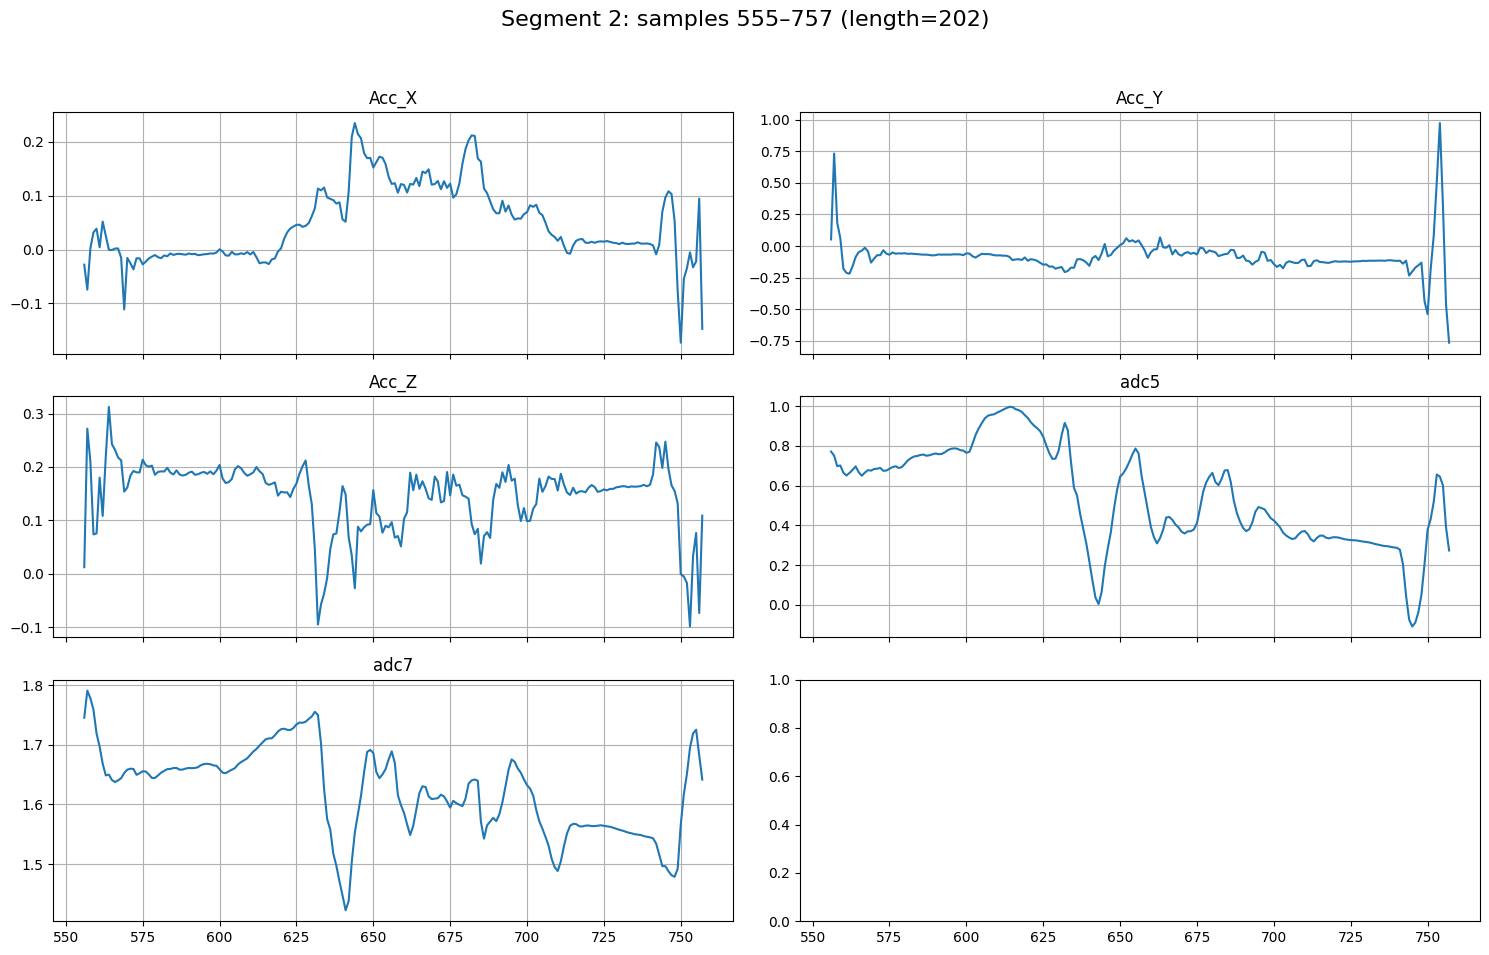

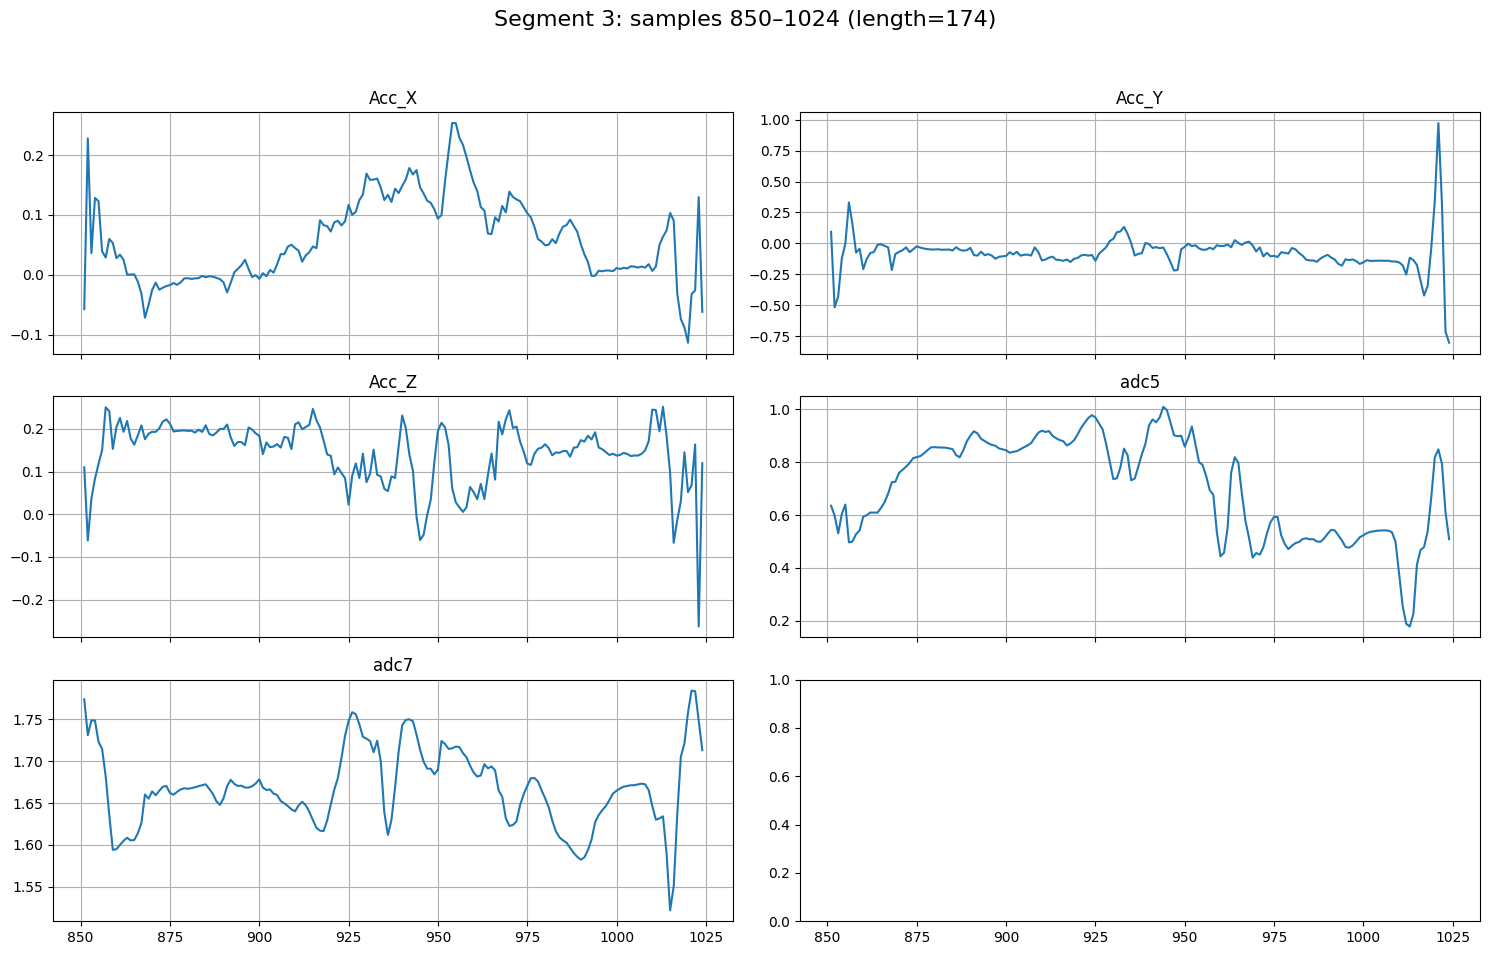

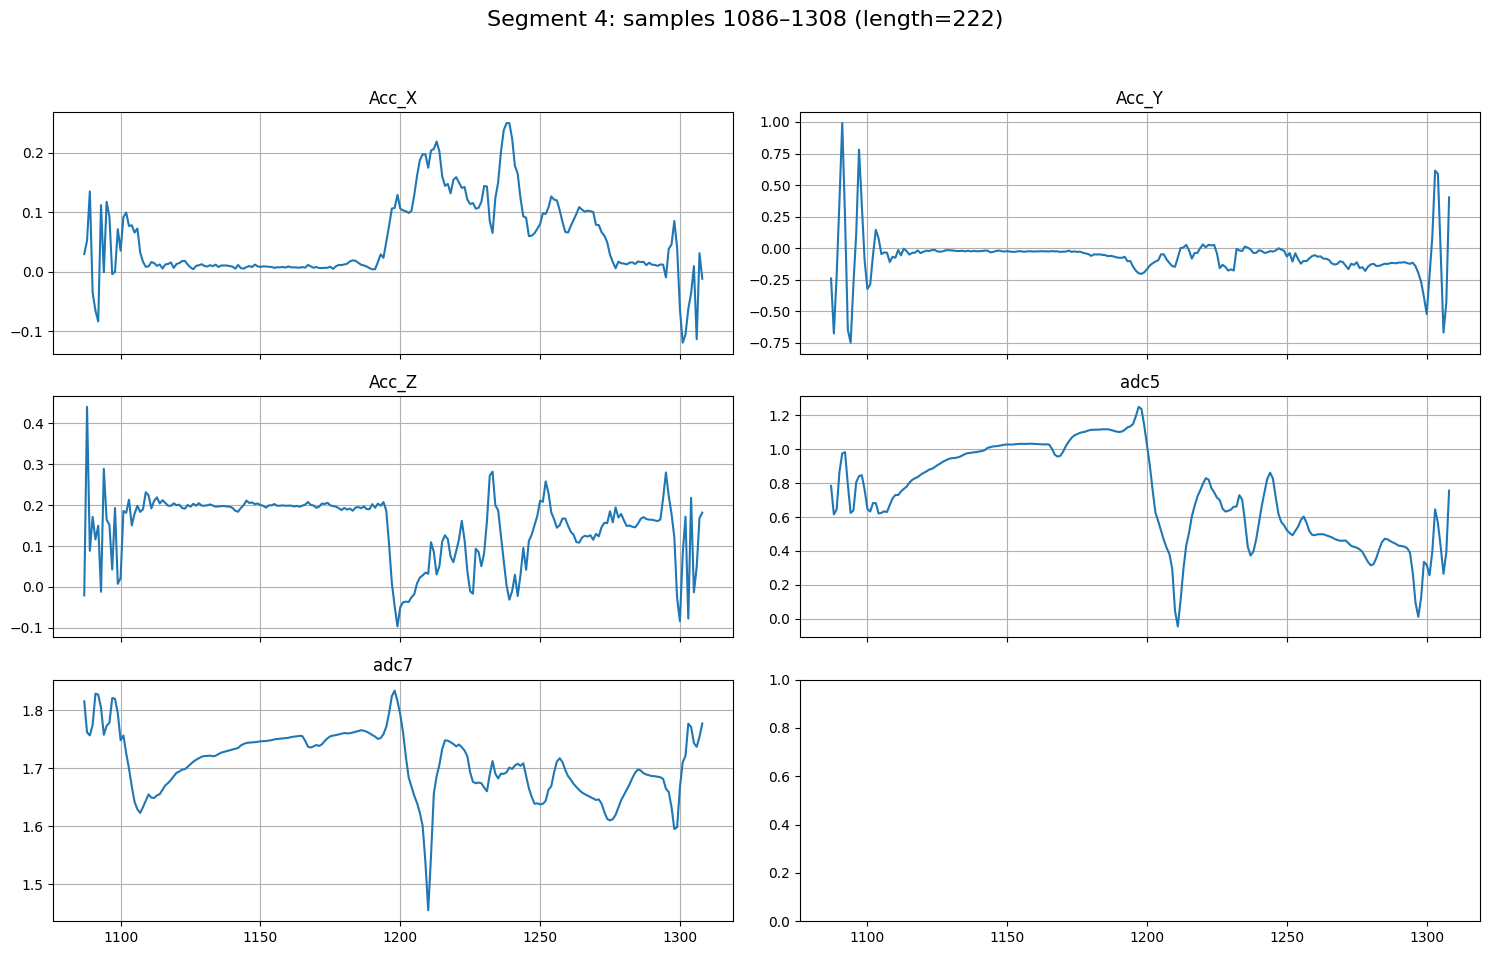

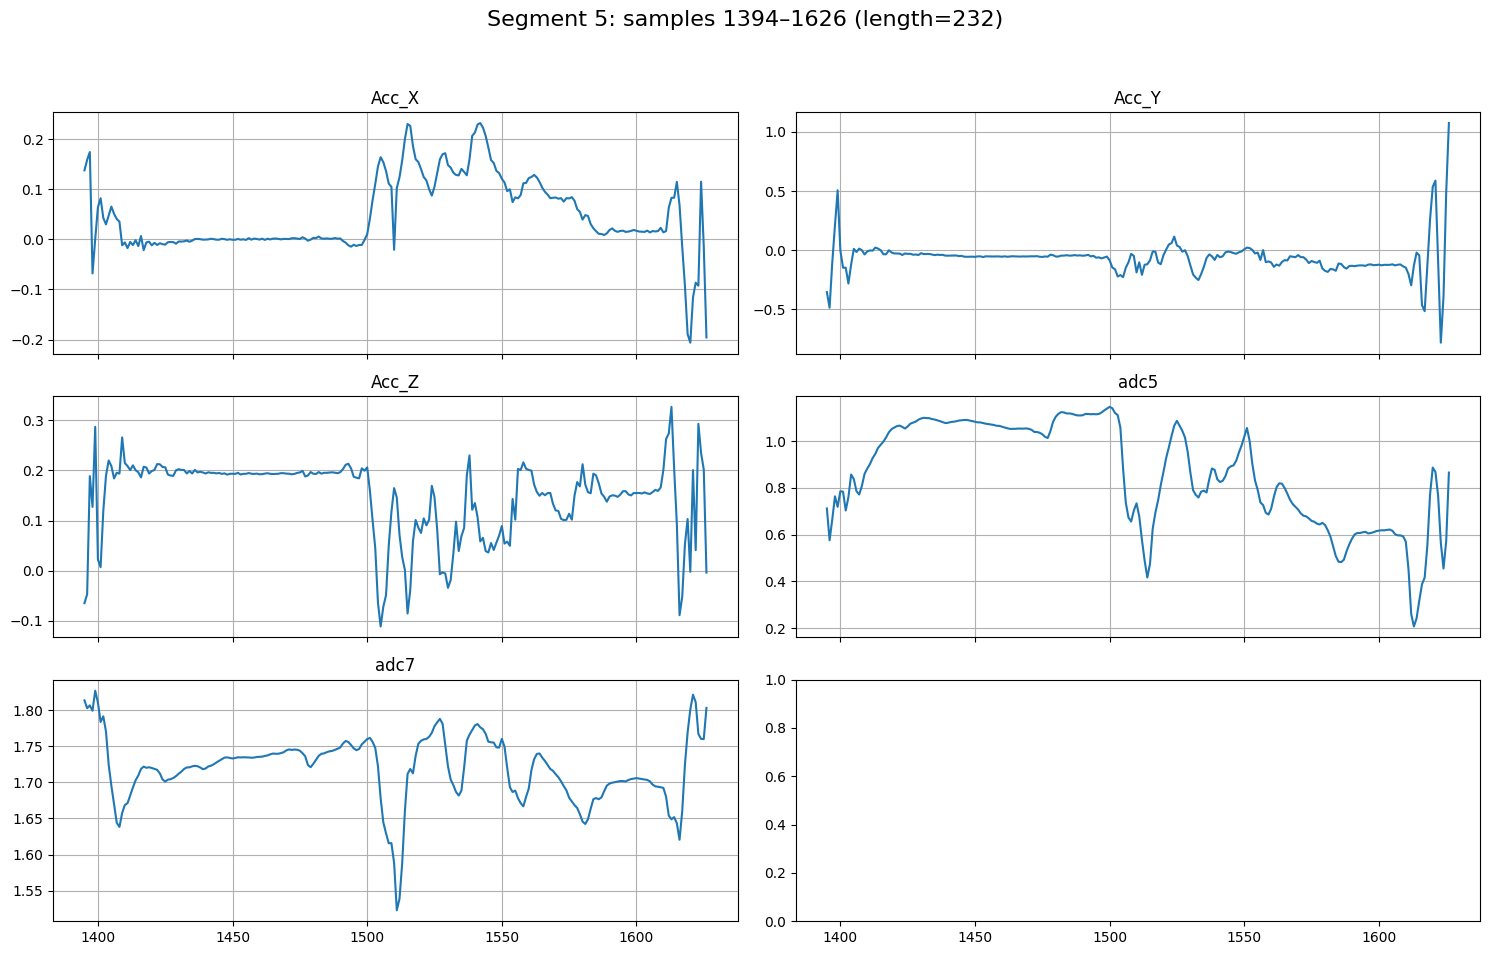

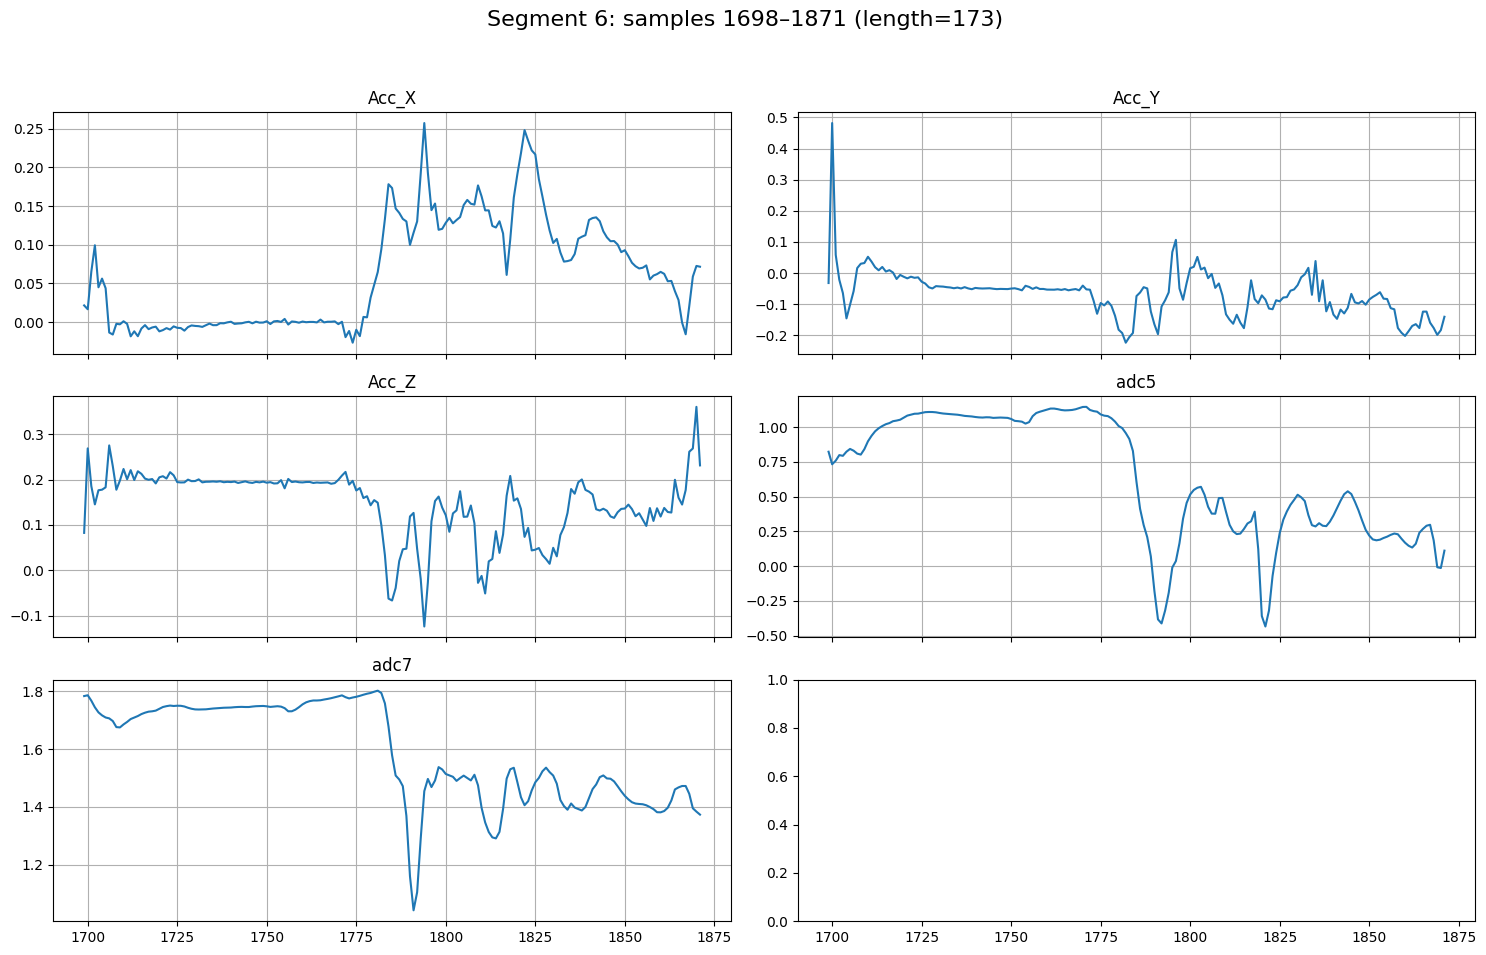

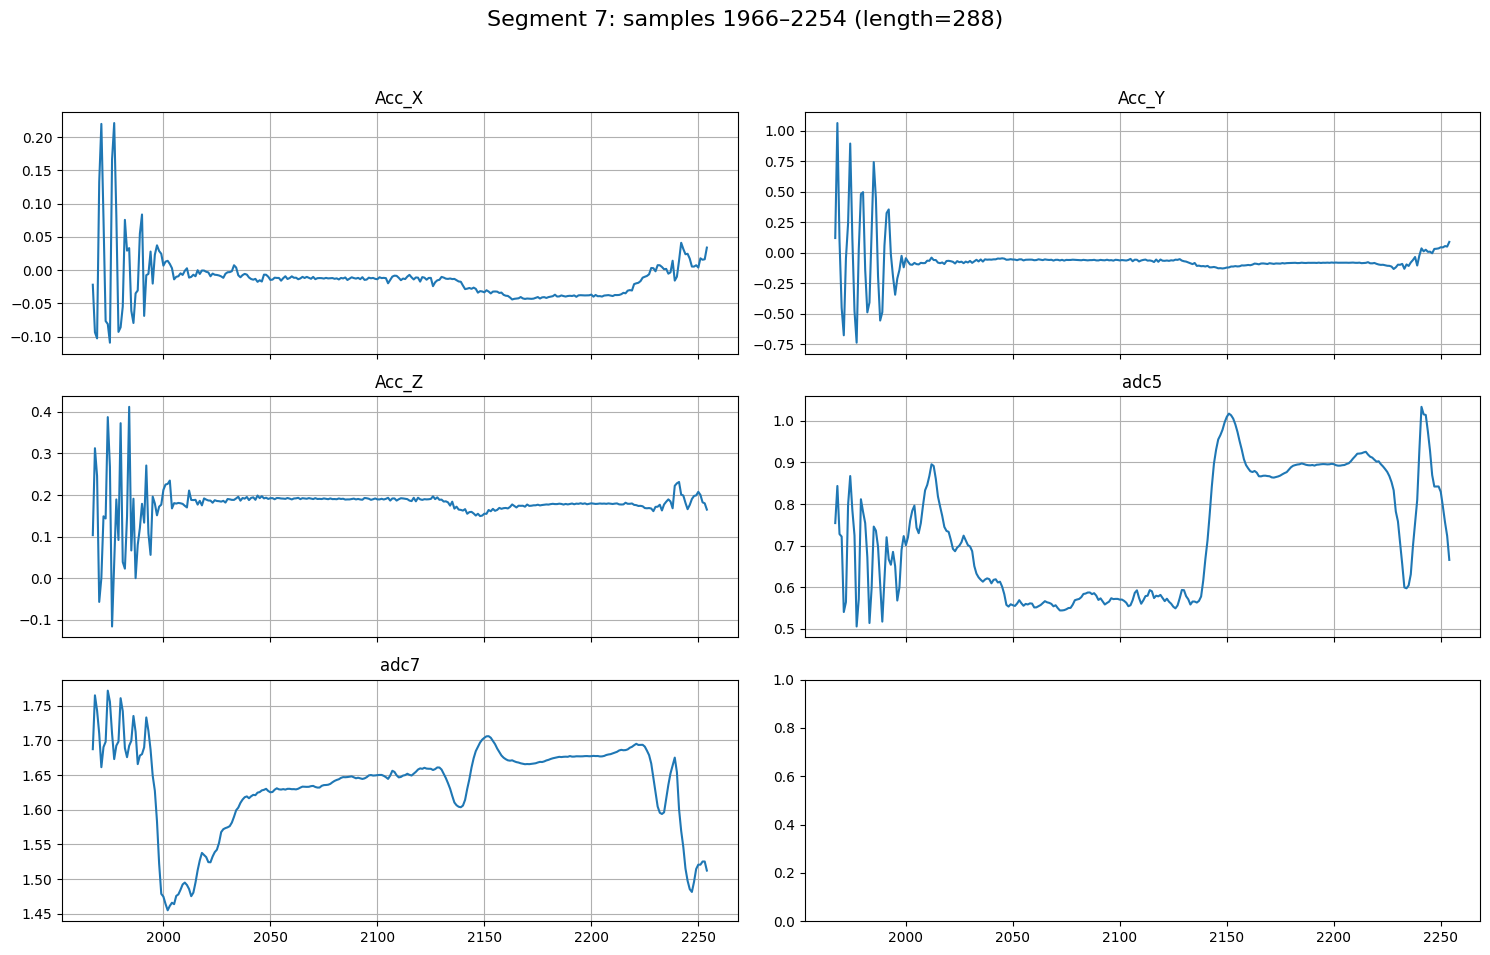

In [28]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# --- 1) 데이터 로드 ---
path = ('/content/drive/MyDrive/watch_ring/250429/01June_2011_Wednesday_heute-944/left_watch/AFELogging_R945USQU1AXC2_6H0K_1.0.57_20240416-113440.csv')

df = pd.read_csv(path, encoding='utf-8')
print(f"데이터 로드 완료: shape = {df.shape}")

# --- 2) 파라미터 (Acc_X/Y/Z 기준) ---
WINDOW        = 7
STD_QUANTILE  = 0.95
MIN_DURATION  = 5
VAL_THRESH    = 20
LENGTH_THRESH = 100
TRIM          = 15   # <-- 앞뒤로 잘라낼 샘플 수

# --- 3) Acc 채널 기반 세그먼트 추출 함수 ---
def extract_acc_segments(df, channels, window, std_q, min_dur, val_thresh, length_thresh):
    rs = df[channels].rolling(window=window, center=True).std().ffill().bfill().fillna(0)
    th = rs.quantile(std_q)
    calm_mask = np.logical_and.reduce([rs[ch] < th[ch] for ch in channels])
    calm_mask = pd.Series(calm_mask, index=df.index)

    diff   = calm_mask.astype(int).diff().fillna(0)
    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0]
    if calm_mask.iloc[0]:
        starts = np.insert(starts, 0, 0)
    if calm_mask.iloc[-1]:
        ends = np.append(ends, len(calm_mask)-1)

    segs = []
    for s, e in zip(starts, ends):
        length = e - s + 1
        if length < min_dur:
            continue
        if df[channels].iloc[s:e+1].abs().max().max() <= val_thresh:
            continue
        if length <= length_thresh:
            continue
        segs.append((s, e))
    return segs

# --- 4) Acc 기반 세그먼트 계산 ---
acc_channels = ['Acc_X','Acc_Y','Acc_Z']
acc_segs = extract_acc_segments(
    df, acc_channels,
    window=WINDOW,
    std_q=STD_QUANTILE,
    min_dur=MIN_DURATION,
    val_thresh=VAL_THRESH,
    length_thresh=LENGTH_THRESH
)
print("원본 Acc 기반 추출 세그먼트:", acc_segs)

# --- 5) aligned_segs 재생성(원본 세그먼트 그대로) ---
ppg_channels = ['adc5','adc7']
all_channels = acc_channels + ppg_channels

aligned_segs = {ch: [] for ch in all_channels}
for s, e in acc_segs:
    for ch in all_channels:
        aligned_segs[ch].append(df[ch].iloc[s:e+1])

# --- 6) 채널별 정규화 함수 정의 ---
def tanh1(x):
    x_scaled = [v * 1e-5 for v in x]
    def _tanh(v):
        v_clip = max(-20, min(20, v))
        return (math.exp(v_clip) - math.exp(-v_clip)) / (math.exp(v_clip) + math.exp(-v_clip))
    out = [_tanh(x_scaled[0])] + [_tanh(v)*2 for v in x_scaled[1:]]
    return [v * 1000 for v in out]

def tanh2(x):
    x_scaled = [v * 1e-5 for v in x]
    def _tanh(v):
        v_clip = max(-20, min(20, v))
        return (math.exp(v_clip) - math.exp(-v_clip)) / (math.exp(v_clip) + math.exp(-v_clip))
    # 첫 원소도 포함해 전부 *2 처리
    return [_tanh(v)*2 for v in x_scaled]

transform_map = {ch: tanh1 for ch in acc_channels}
transform_map.update({ch: tanh2 for ch in ppg_channels})

# --- 7) 시각화: ACC 채널 전체 + 세그먼트 오버레이 (원본 그대로) ---
for ch in acc_channels:
    plt.figure(figsize=(12, 3))
    plt.plot(df[ch], color='lightgray', label='Original')
    for idx, seg in enumerate(aligned_segs[ch], 1):
        plt.plot(seg.index, seg.values, '.', markersize=4, label=f'S{idx}')
    plt.title(f'{ch} — Calm Segments Overlay')
    plt.xlabel('Sample Index')
    plt.ylabel(ch)
    plt.legend(fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for idx, (s, e) in enumerate(acc_segs, 1):
    seg_df = df.iloc[s+1:e+1]                             # 모든 채널이 포함된 DataFrame 슬라이스
    fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
    axes = axes.flatten()

    for ax, ch in zip(axes, all_channels):
        raw  = seg_df[ch].tolist()                      # 해당 채널의 원본 값
        norm = transform_map[ch](raw)                   # tanh1/tanh2 적용

        ax.plot(seg_df.index, norm)                     # x축: 원본 인덱스
        ax.set_title(ch)
        ax.grid(True)

    fig.suptitle(
        f'Segment {idx}: samples {s}–{e} (length={e-s})',
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



데이터 로드 완료: shape = (2376, 15)
원본 Acc 기반 추출 세그먼트: [(np.int64(0), np.int64(321)), (np.int64(453), np.int64(622)), (np.int64(719), np.int64(922)), (np.int64(1018), np.int64(1191)), (np.int64(1239), np.int64(1477)), (np.int64(1568), np.int64(1799)), (np.int64(1869), np.int64(2042)), (np.int64(2164), np.int64(2375))]


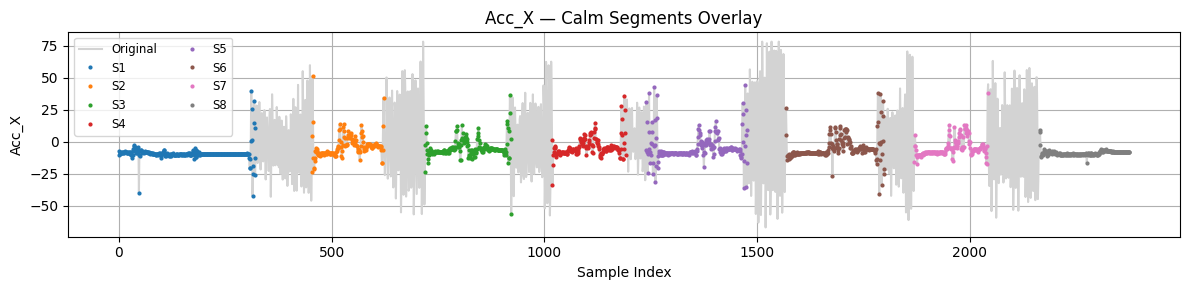

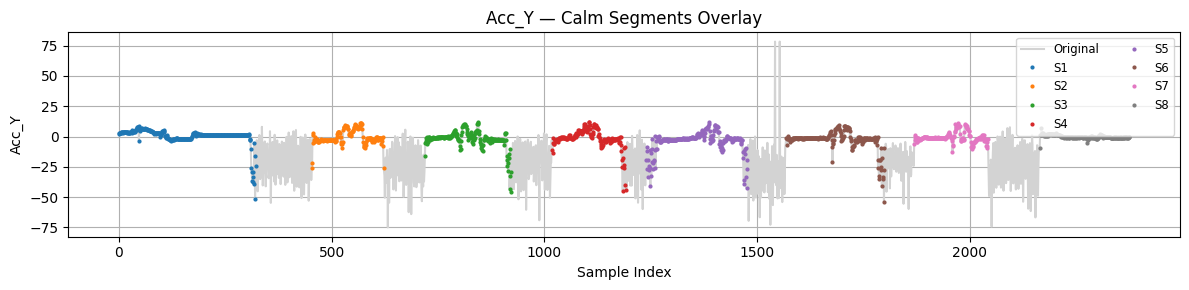

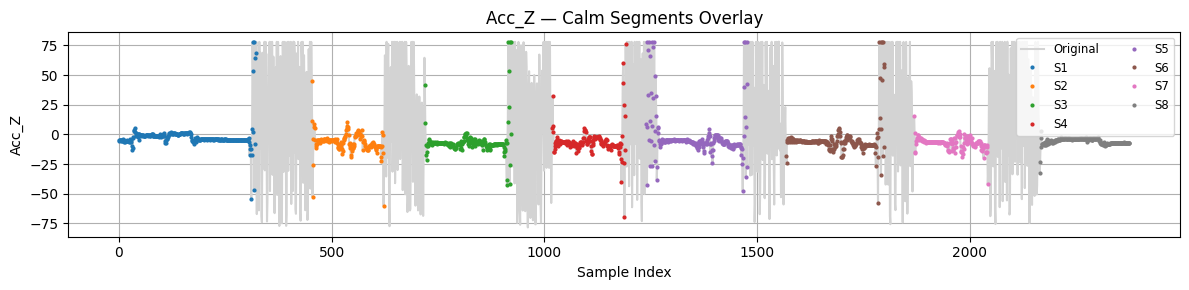

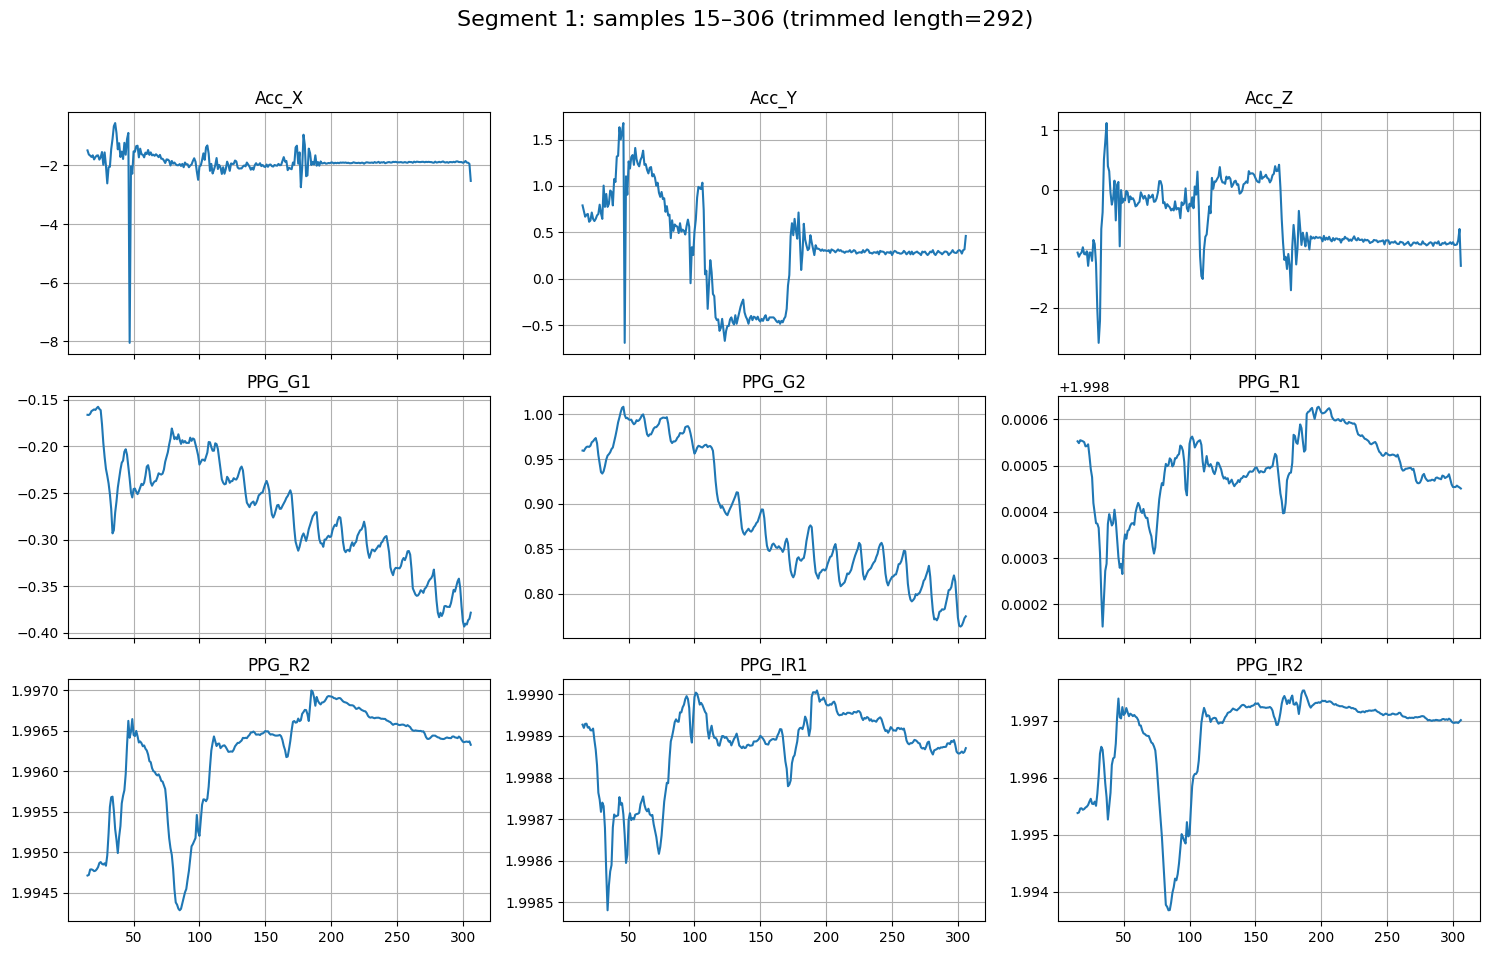

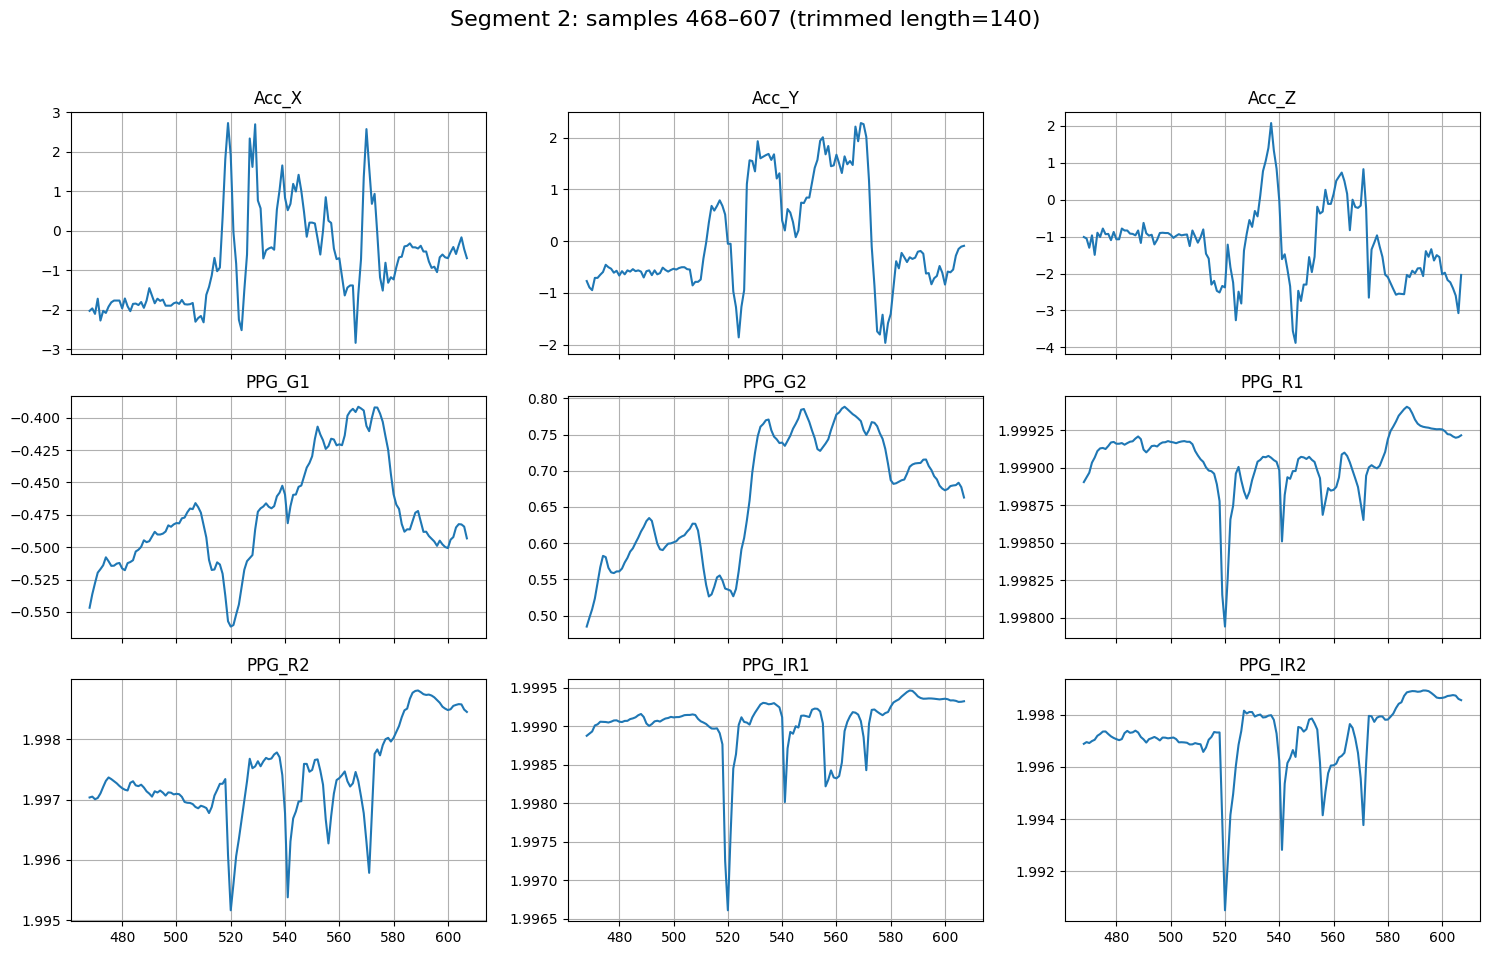

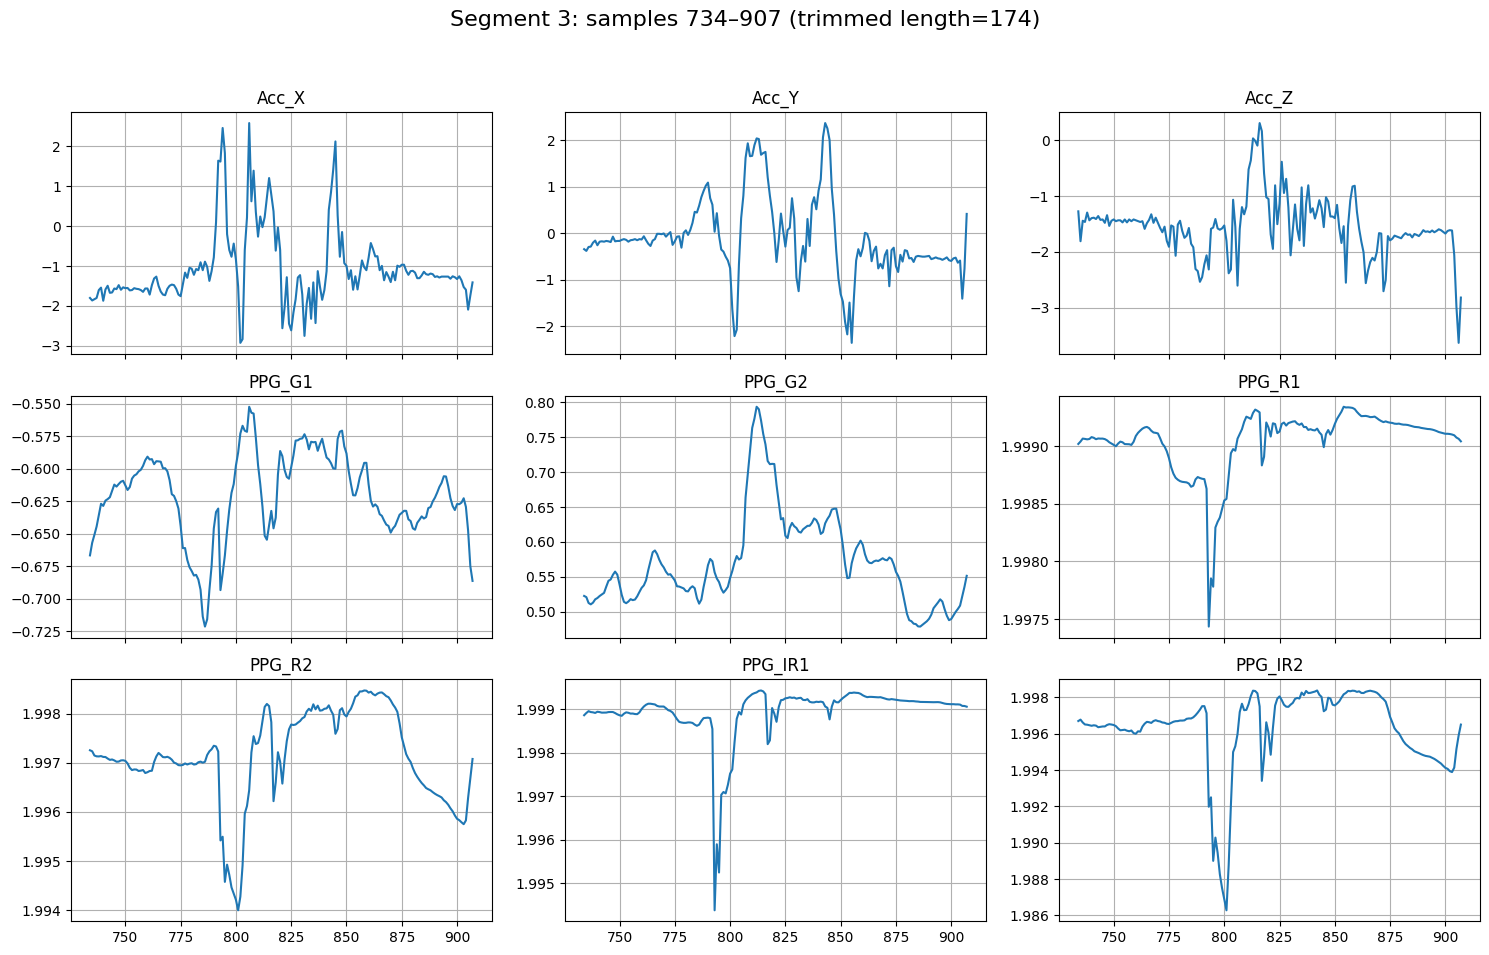

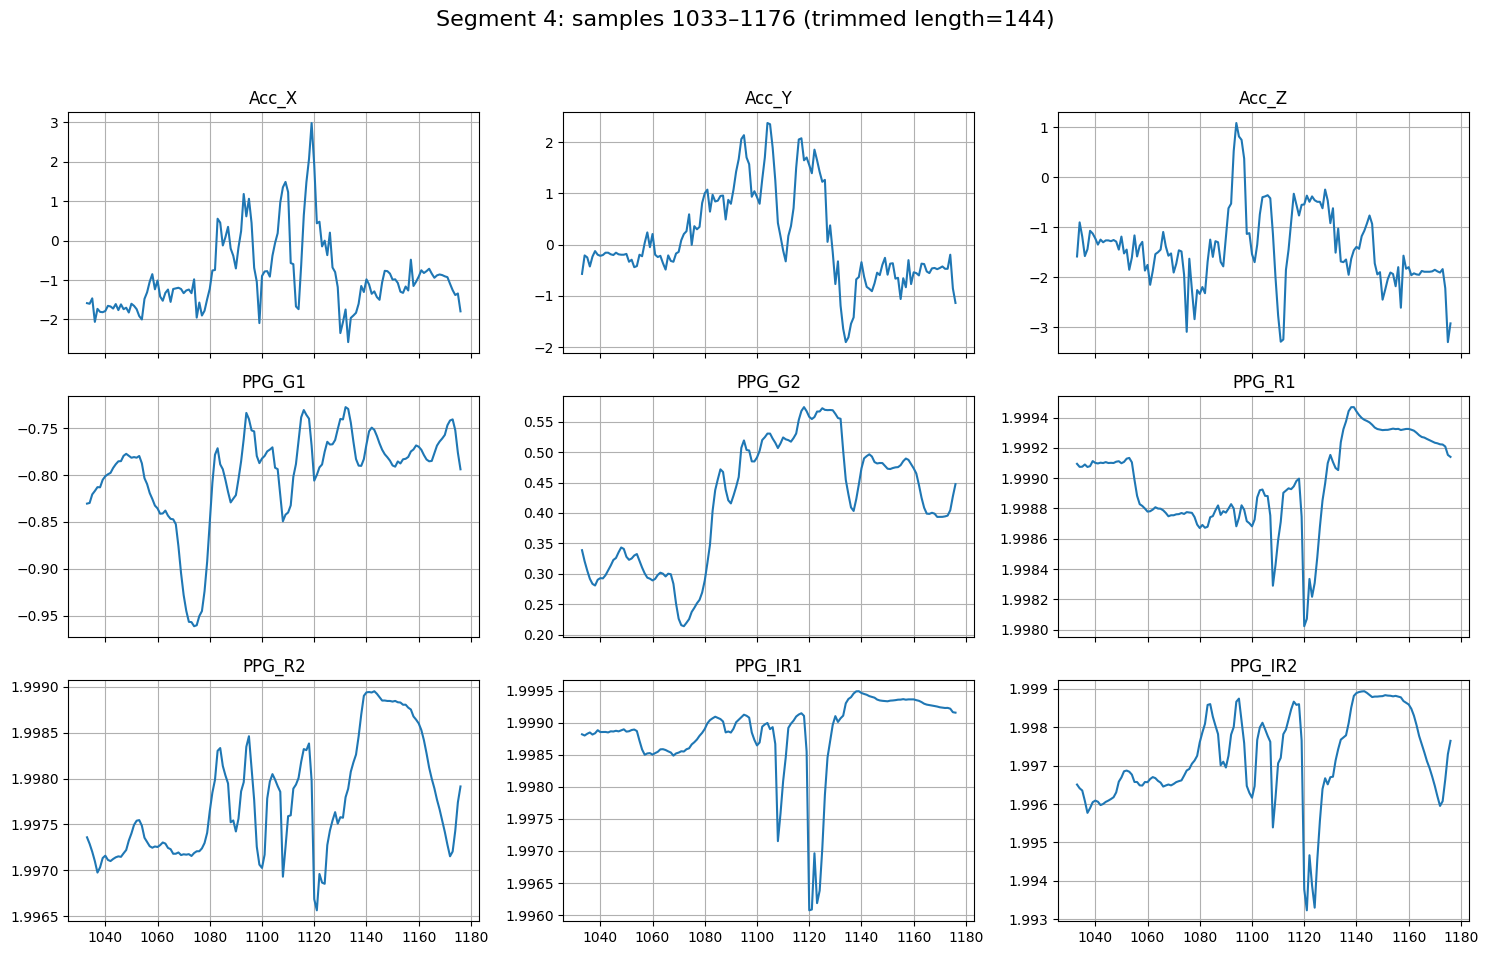

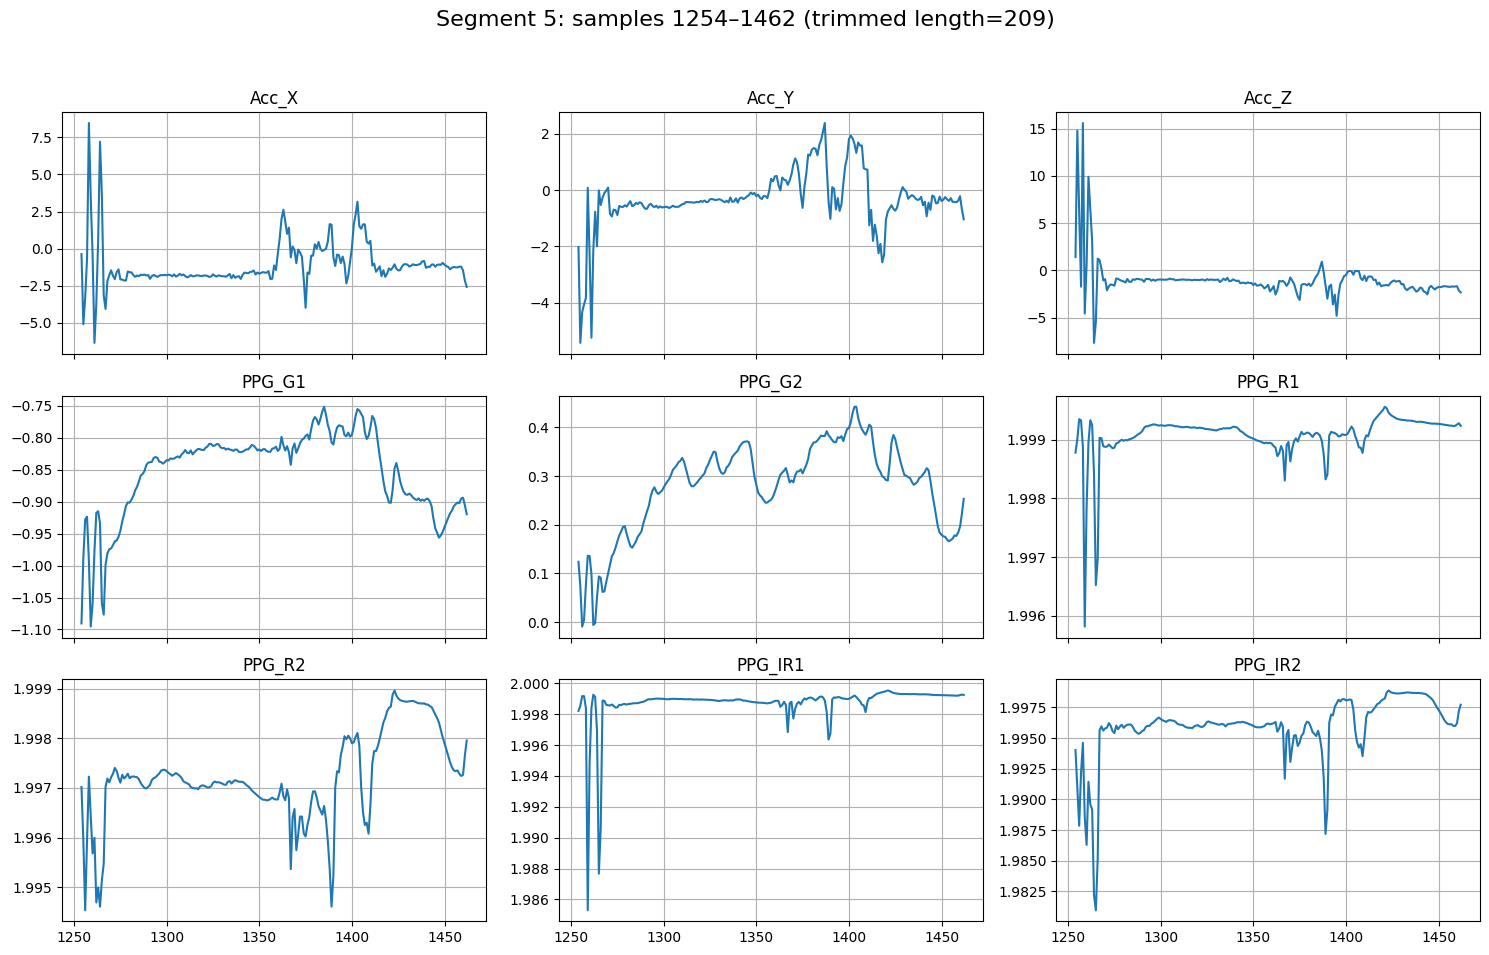

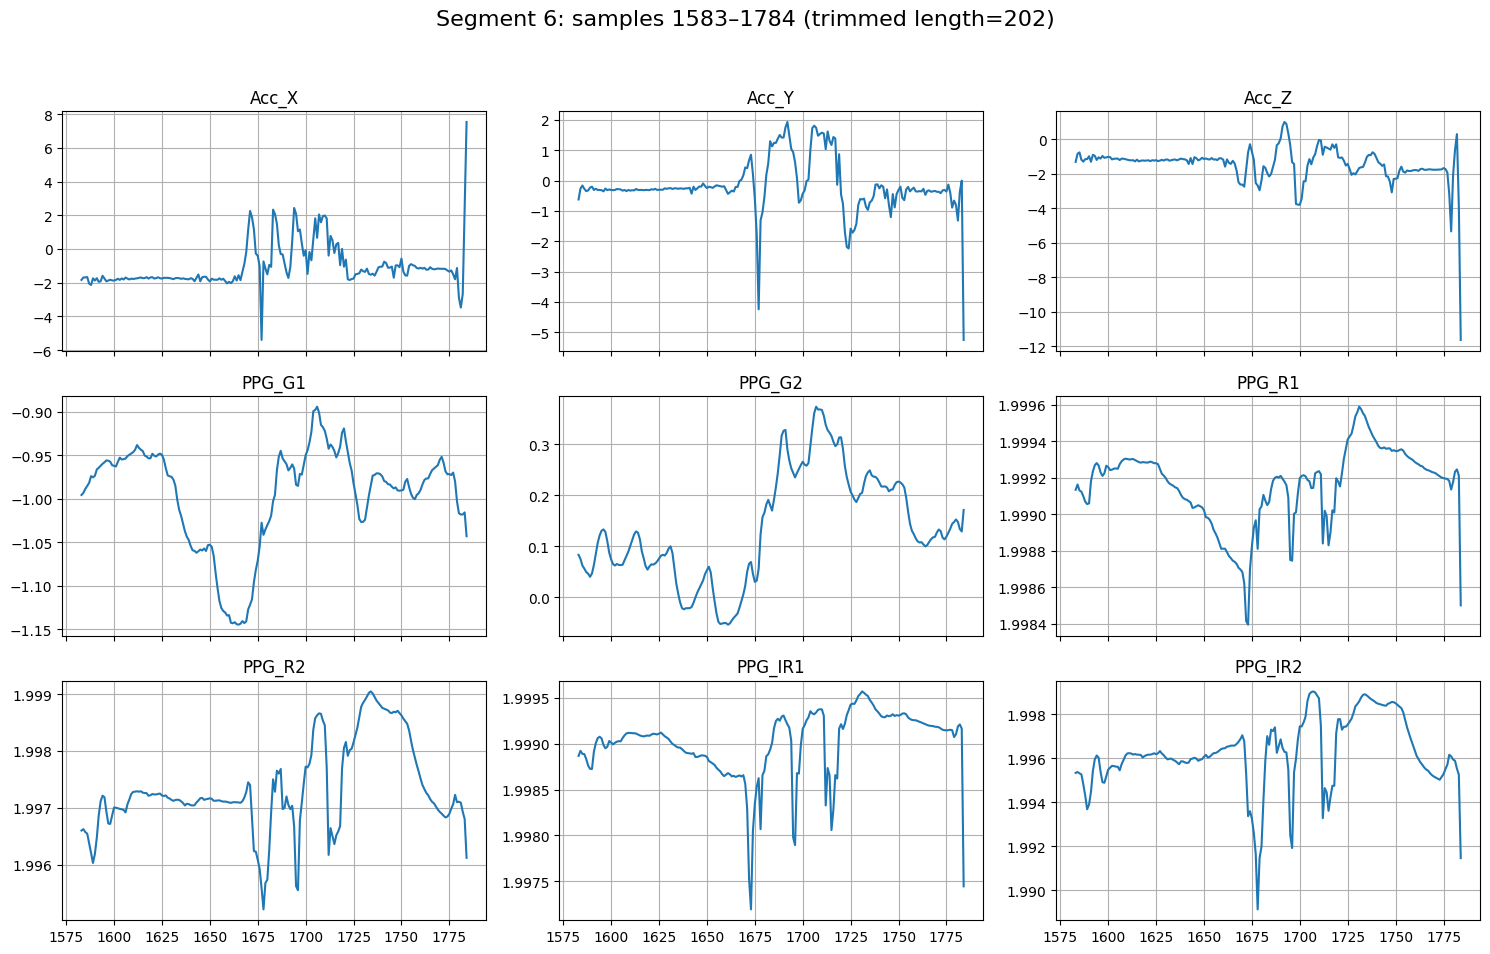

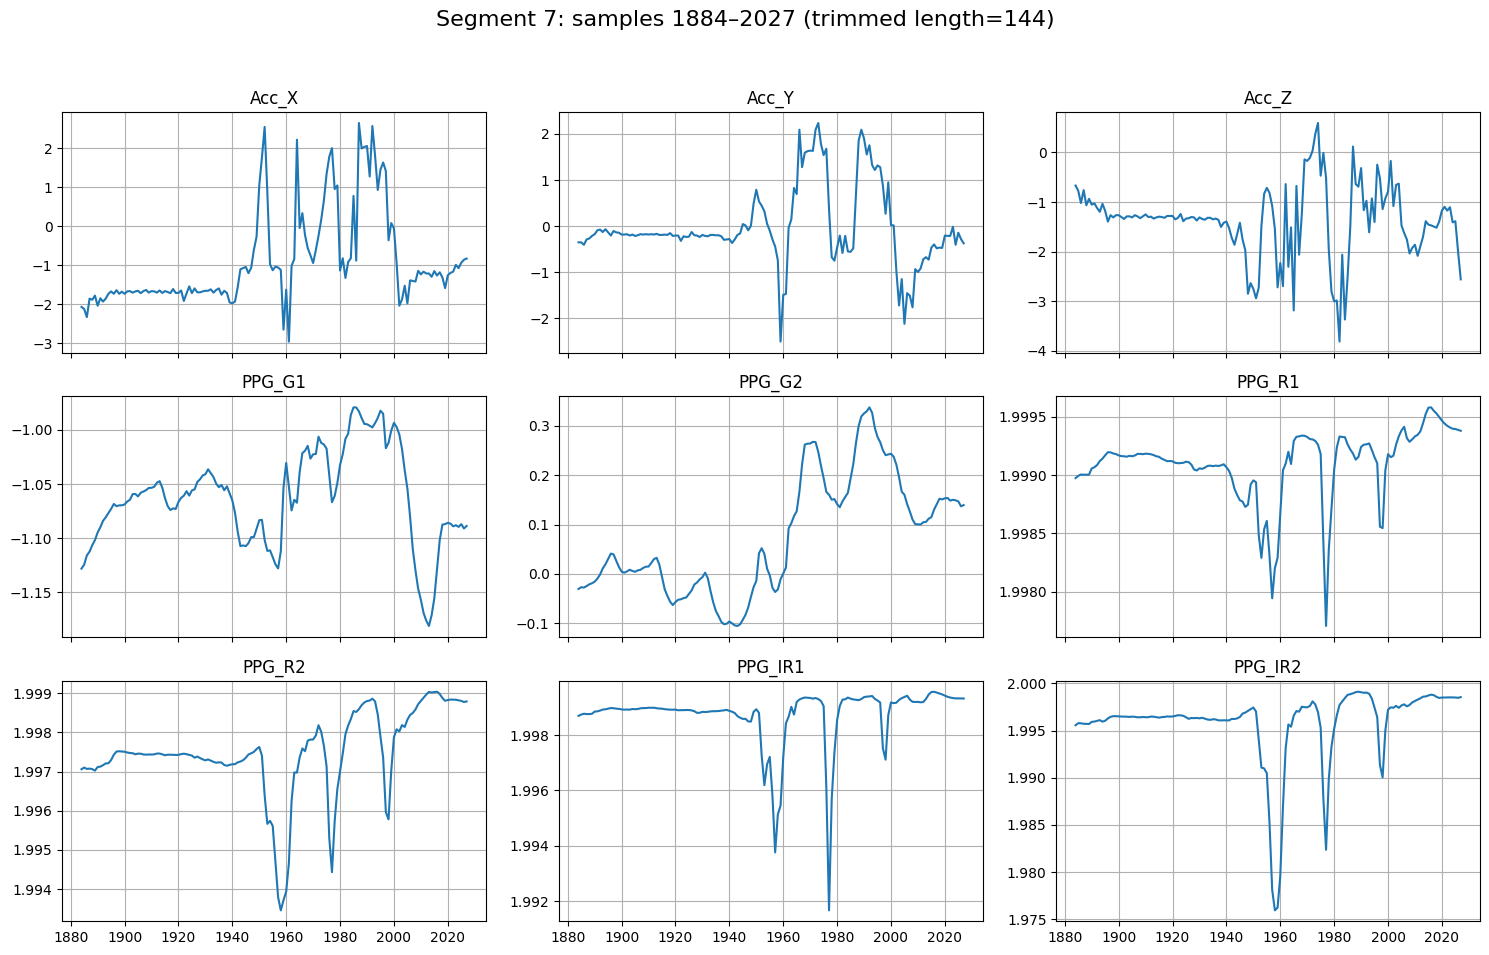

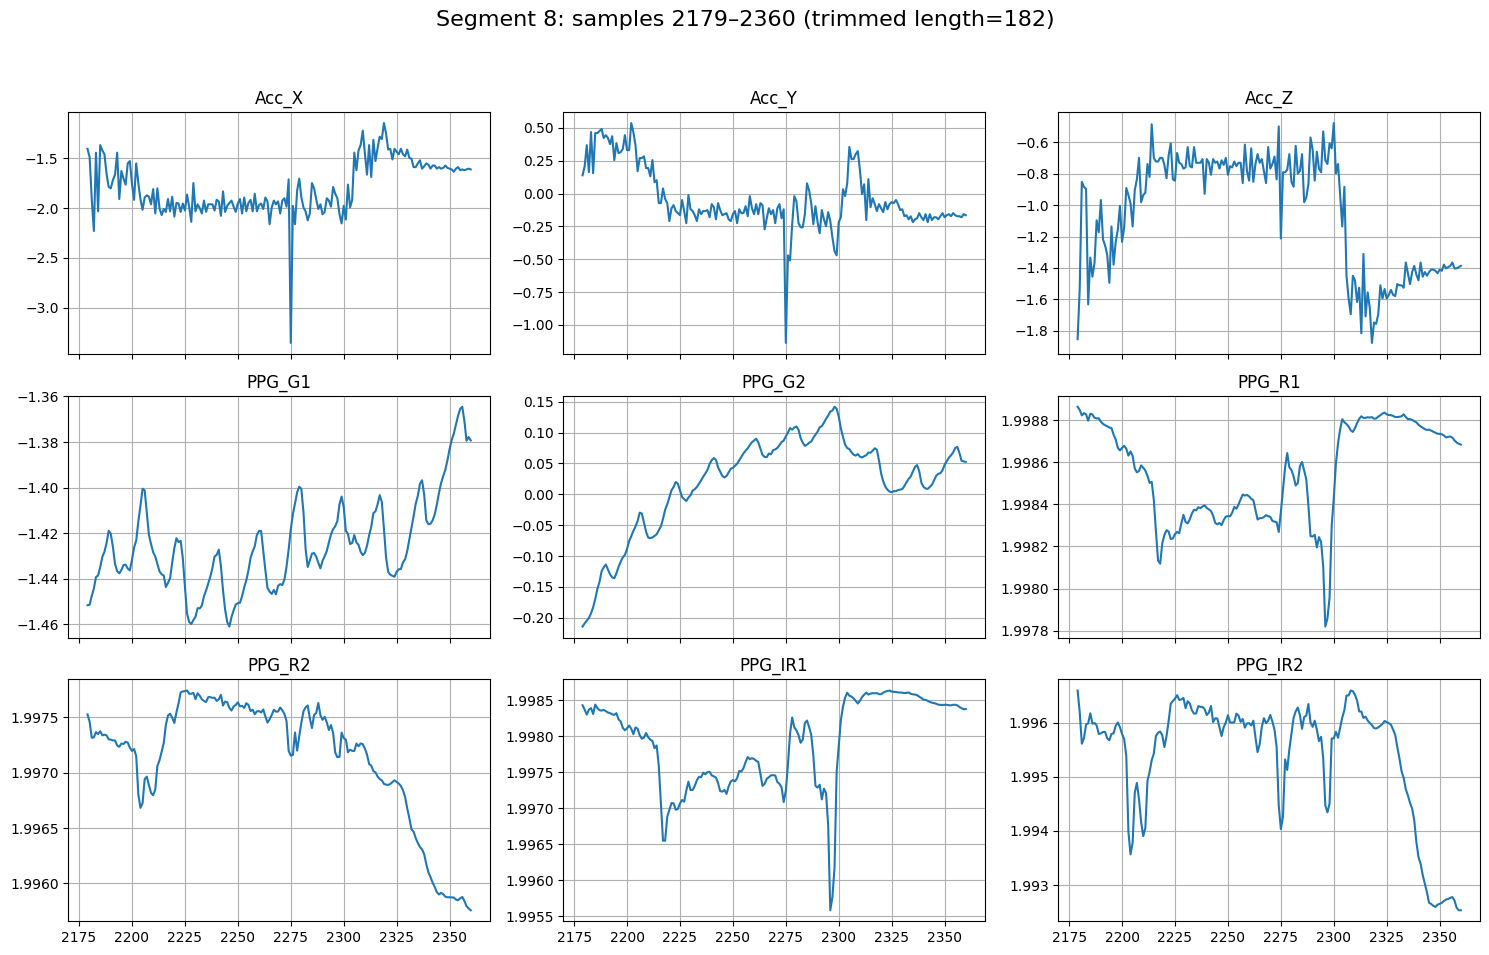

In [31]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# --- 1) 데이터 로드 ---
path = (
    '/content/drive/MyDrive/watch_ring/250429/01June_2011_Wednesday_heute-944/'
    'left_ring/RingSpO2_Id000001023_DevF952_NoDev_1745889855205_'
    'P09_20250429_102415_HRIBI.csv'
)
df = pd.read_csv(path, encoding='utf-8')
print(f"데이터 로드 완료: shape = {df.shape}")

# --- 2) 파라미터 (Acc_X/Y/Z 기준) ---
WINDOW        = 7
STD_QUANTILE  = 0.93
MIN_DURATION  = 5
VAL_THRESH    = 20
LENGTH_THRESH = 100
TRIM          = 15   # <-- 앞뒤로 잘라낼 샘플 수

# --- 3) Acc 채널 기반 세그먼트 추출 함수 ---
def extract_acc_segments(df, channels, window, std_q, min_dur, val_thresh, length_thresh):
    rs = df[channels].rolling(window=window, center=True).std().ffill().bfill().fillna(0)
    th = rs.quantile(std_q)
    calm_mask = np.logical_and.reduce([rs[ch] < th[ch] for ch in channels])
    calm_mask = pd.Series(calm_mask, index=df.index)

    diff   = calm_mask.astype(int).diff().fillna(0)
    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0]
    if calm_mask.iloc[0]:
        starts = np.insert(starts, 0, 0)
    if calm_mask.iloc[-1]:
        ends = np.append(ends, len(calm_mask)-1)

    segs = []
    for s, e in zip(starts, ends):
        length = e - s + 1
        if length < min_dur:
            continue
        if df[channels].iloc[s:e+1].abs().max().max() <= val_thresh:
            continue
        if length <= length_thresh:
            continue
        segs.append((s, e))
    return segs

# --- 4) Acc 기반 세그먼트 계산 ---
acc_channels = ['Acc_X','Acc_Y','Acc_Z']
acc_segs = extract_acc_segments(
    df, acc_channels,
    window=WINDOW,
    std_q=STD_QUANTILE,
    min_dur=MIN_DURATION,
    val_thresh=VAL_THRESH,
    length_thresh=LENGTH_THRESH
)
print("원본 Acc 기반 추출 세그먼트:", acc_segs)

# --- 5) aligned_segs 재생성(원본 세그먼트 그대로) ---
ppg_channels = ['PPG_G1','PPG_G2','PPG_R1','PPG_R2','PPG_IR1','PPG_IR2']
all_channels = acc_channels + ppg_channels

aligned_segs = {ch: [] for ch in all_channels}
for s, e in acc_segs:
    for ch in all_channels:
        aligned_segs[ch].append(df[ch].iloc[s:e+1])

# --- 6) 채널별 정규화 함수 정의 ---
def tanh1(x):
    x_scaled = [v * 1e-5 for v in x]
    def _tanh(v):
        v_clip = max(-20, min(20, v))
        return (math.exp(v_clip) - math.exp(-v_clip)) / (math.exp(v_clip) + math.exp(-v_clip))
    out = [_tanh(x_scaled[0])] + [_tanh(v)*2 for v in x_scaled[1:]]
    return [v * 10000 for v in out]

def tanh2(x):
    x_scaled = [v * 1e-5 for v in x]
    def _tanh(v):
        v_clip = max(-20, min(20, v))
        return (math.exp(v_clip) - math.exp(-v_clip)) / (math.exp(v_clip) + math.exp(-v_clip))
    # 첫 원소도 포함해 전부 *2 처리
    return [_tanh(v)*2 for v in x_scaled]

transform_map = {ch: tanh1 for ch in acc_channels}
transform_map.update({ch: tanh2 for ch in ppg_channels})

# --- 7) 시각화: ACC 채널 전체 + 세그먼트 오버레이 (원본 그대로) ---
for ch in acc_channels:
    plt.figure(figsize=(12, 3))
    plt.plot(df[ch], color='lightgray', label='Original')
    for idx, seg in enumerate(aligned_segs[ch], 1):
        plt.plot(seg.index, seg.values, '.', markersize=4, label=f'S{idx}')
    plt.title(f'{ch} — Calm Segments Overlay')
    plt.xlabel('Sample Index')
    plt.ylabel(ch)
    plt.legend(fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 8) 최종: 세그먼트별 3×3 플롯 (tanh → trim 순서) ---
for idx, (s, e) in enumerate(acc_segs, 1):
    raw_seg = df.iloc[s:e+1]
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
    axes = axes.flatten()

    for ax, ch in zip(axes, all_channels):
        # 1) 전체 raw segment에 tanh 적용
        norm_full = transform_map[ch]( raw_seg[ch].tolist() )
        # 2) 적용 후 앞뒤 TRIM만큼 잘라내기
        norm_trim = norm_full[TRIM : len(norm_full)-TRIM]
        idxs = raw_seg.index[TRIM : len(raw_seg)-TRIM]

        ax.plot(idxs, norm_trim)
        ax.set_title(ch)
        ax.grid(True)

    # 남은 축 없애기
    for ax in axes[len(all_channels):]:
        ax.axis('off')

    fig.suptitle(
        f'Segment {idx}: samples {s+TRIM}–{e-TRIM} (trimmed length={e-s+1-2*TRIM})',
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
